In [75]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.pipeline import Pipeline

# -------------------------
# Classification Models
# -------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

# -------------------------
# Regression Models
# -------------------------

from sklearn.linear_model import LinearRegression

from sklearn.neighbors import KNeighborsRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# -------------------------
# Classification Metrics
# -------------------------

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# -------------------------
# Regression Metrics
# -------------------------

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import shap

In [5]:
# Check available splits
print(ds)

# Convert train split to pandas DataFrame
df = ds["train"].to_pandas()

# Save as CSV
df.to_csv("digital_lifestyle_benchmark.csv", index=False)

print("CSV saved successfully!")

DatasetDict({
    train: Dataset({
        features: ['id', 'age', 'gender', 'region', 'income_level', 'education_level', 'daily_role', 'device_hours_per_day', 'phone_unlocks', 'notifications_per_day', 'social_media_mins', 'study_mins', 'physical_activity_days', 'sleep_hours', 'sleep_quality', 'anxiety_score', 'depression_score', 'stress_level', 'happiness_score', 'focus_score', 'high_risk_flag', 'device_type', 'productivity_score', 'digital_dependence_score'],
        num_rows: 3500
    })
})
CSV saved successfully!


In [7]:
df.to_csv("C:/Users/anmnu/DSML/final-project/digital_lifestyle_benchmark.csv", index=False)

In [3]:
import pandas as pd
df = pd.read_csv("C:/Users/anmnu/DSML/final-project/digital_lifestyle_benchmark.csv")

In [4]:
df

,id,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,...,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score
0,1,40,Female,Asia,High,High School,Part-time/Shift,3.54,45,561,...,3.353627,9.926651,5.0,6.593289,8.0,23.0,0,Android,70.000000,25.700000
1,2,27,Male,Africa,Lower-Mid,Master,Full-time Employee,5.65,100,393,...,2.908147,4.000000,4.0,4.126926,8.1,35.0,0,Laptop,64.000000,30.100000
2,3,31,Male,North America,Lower-Mid,Bachelor,Full-time Employee,8.87,181,231,...,2.889213,4.000000,8.0,1.429139,7.6,15.0,0,Android,65.299301,40.600000
3,4,41,Female,Middle East,Low,Master,Caregiver/Home,4.05,94,268,...,3.097488,7.093357,9.0,4.995512,7.8,28.0,1,Tablet,80.000000,36.684152
4,5,26,Female,Europe,Lower-Mid,Bachelor,Full-time Employee,13.07,199,91,...,2.786098,7.028125,15.0,9.448757,4.2,70.0,1,Android,65.299301,48.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,3496,15,Female,Africa,Low,High School,Part-time/Shift,6.41,119,308,...,2.950001,4.772862,9.0,7.076726,2.4,59.0,0,Laptop,84.000000,29.600000
3496,3497,28,Female,Europe,High,Bachelor,Part-time/Shift,4.21,55,415,...,3.124953,5.520824,2.0,1.000000,8.9,27.0,1,Laptop,73.000000,23.200000
3497,3498,44,Female,Europe,Lower-Mid,Bachelor,Part-time/Shift,11.51,146,119,...,2.269790,8.518051,11.0,1.783568,7.6,56.0,0,Android,65.000000,42.400000
3498,3499,29,Female,North America,Low,Master,Full-time Employee,5.13,63,180,...,4.902579,4.238655,8.0,10.000000,2.8,52.0,0,Laptop,63.000000,20.500000


In [5]:
df.describe()

,id,age,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,study_mins,physical_activity_days,sleep_hours,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,productivity_score,digital_dependence_score
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,1750.500000,28.078571,7.317677,147.107429,335.117143,159.362857,108.116571,3.350000,7.254481,2.708848,7.183858,8.830000,5.076560,6.418568,41.598600,0.201429,65.299301,36.684152
std,1010.507298,9.352385,3.239838,67.770656,239.678612,132.748048,79.796273,1.877976,1.291879,1.101105,5.043220,5.738959,3.403503,3.019828,23.764574,0.401125,9.664716,14.115504
min,1.000000,13.000000,0.280000,9.000000,22.000000,0.000000,0.000000,0.000000,3.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,33.000000,5.600000
25%,875.750000,21.000000,4.867500,96.000000,170.000000,68.000000,42.000000,2.000000,6.410545,1.919438,4.000000,4.000000,1.341488,4.000000,24.750000,0.000000,59.000000,26.200000
50%,1750.500000,27.000000,6.760000,136.000000,268.000000,119.000000,102.000000,3.000000,7.291580,2.907819,6.000000,8.000000,4.809726,7.500000,44.000000,0.000000,65.299301,35.300000
75%,2625.250000,34.000000,9.152500,187.000000,434.000000,204.000000,163.000000,5.000000,8.162298,3.276968,8.845008,13.000000,8.794302,8.900000,59.000000,0.000000,71.000000,45.100000
max,3500.000000,50.000000,17.160000,374.000000,1211.000000,631.000000,418.000000,7.000000,11.004566,5.000000,27.154217,27.000000,10.000000,10.000000,100.000000,1.000000,95.000000,89.200000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        3500 non-null   int64  
 1   age                       3500 non-null   int64  
 2   gender                    3500 non-null   object 
 3   region                    3500 non-null   object 
 4   income_level              3500 non-null   object 
 5   education_level           3500 non-null   object 
 6   daily_role                3500 non-null   object 
 7   device_hours_per_day      3500 non-null   float64
 8   phone_unlocks             3500 non-null   int64  
 9   notifications_per_day     3500 non-null   int64  
 10  social_media_mins         3500 non-null   int64  
 11  study_mins                3500 non-null   int64  
 12  physical_activity_days    3500 non-null   float64
 13  sleep_hours               3500 non-null   float64
 14  sleep_qu

In [7]:
df.isna().sum()

id                          0
age                         0
gender                      0
region                      0
income_level                0
education_level             0
daily_role                  0
device_hours_per_day        0
phone_unlocks               0
notifications_per_day       0
social_media_mins           0
study_mins                  0
physical_activity_days      0
sleep_hours                 0
sleep_quality               0
anxiety_score               0
depression_score            0
stress_level                0
happiness_score             0
focus_score                 0
high_risk_flag              0
device_type                 0
productivity_score          0
digital_dependence_score    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
continuous_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(continuous_cols)
print(categorical_cols)

Index(['id', 'age', 'device_hours_per_day', 'phone_unlocks',
       'notifications_per_day', 'social_media_mins', 'study_mins',
       'physical_activity_days', 'sleep_hours', 'sleep_quality',
       'anxiety_score', 'depression_score', 'stress_level', 'happiness_score',
       'focus_score', 'high_risk_flag', 'productivity_score',
       'digital_dependence_score'],
      dtype='object')
Index(['gender', 'region', 'income_level', 'education_level', 'daily_role',
       'device_type'],
      dtype='object')


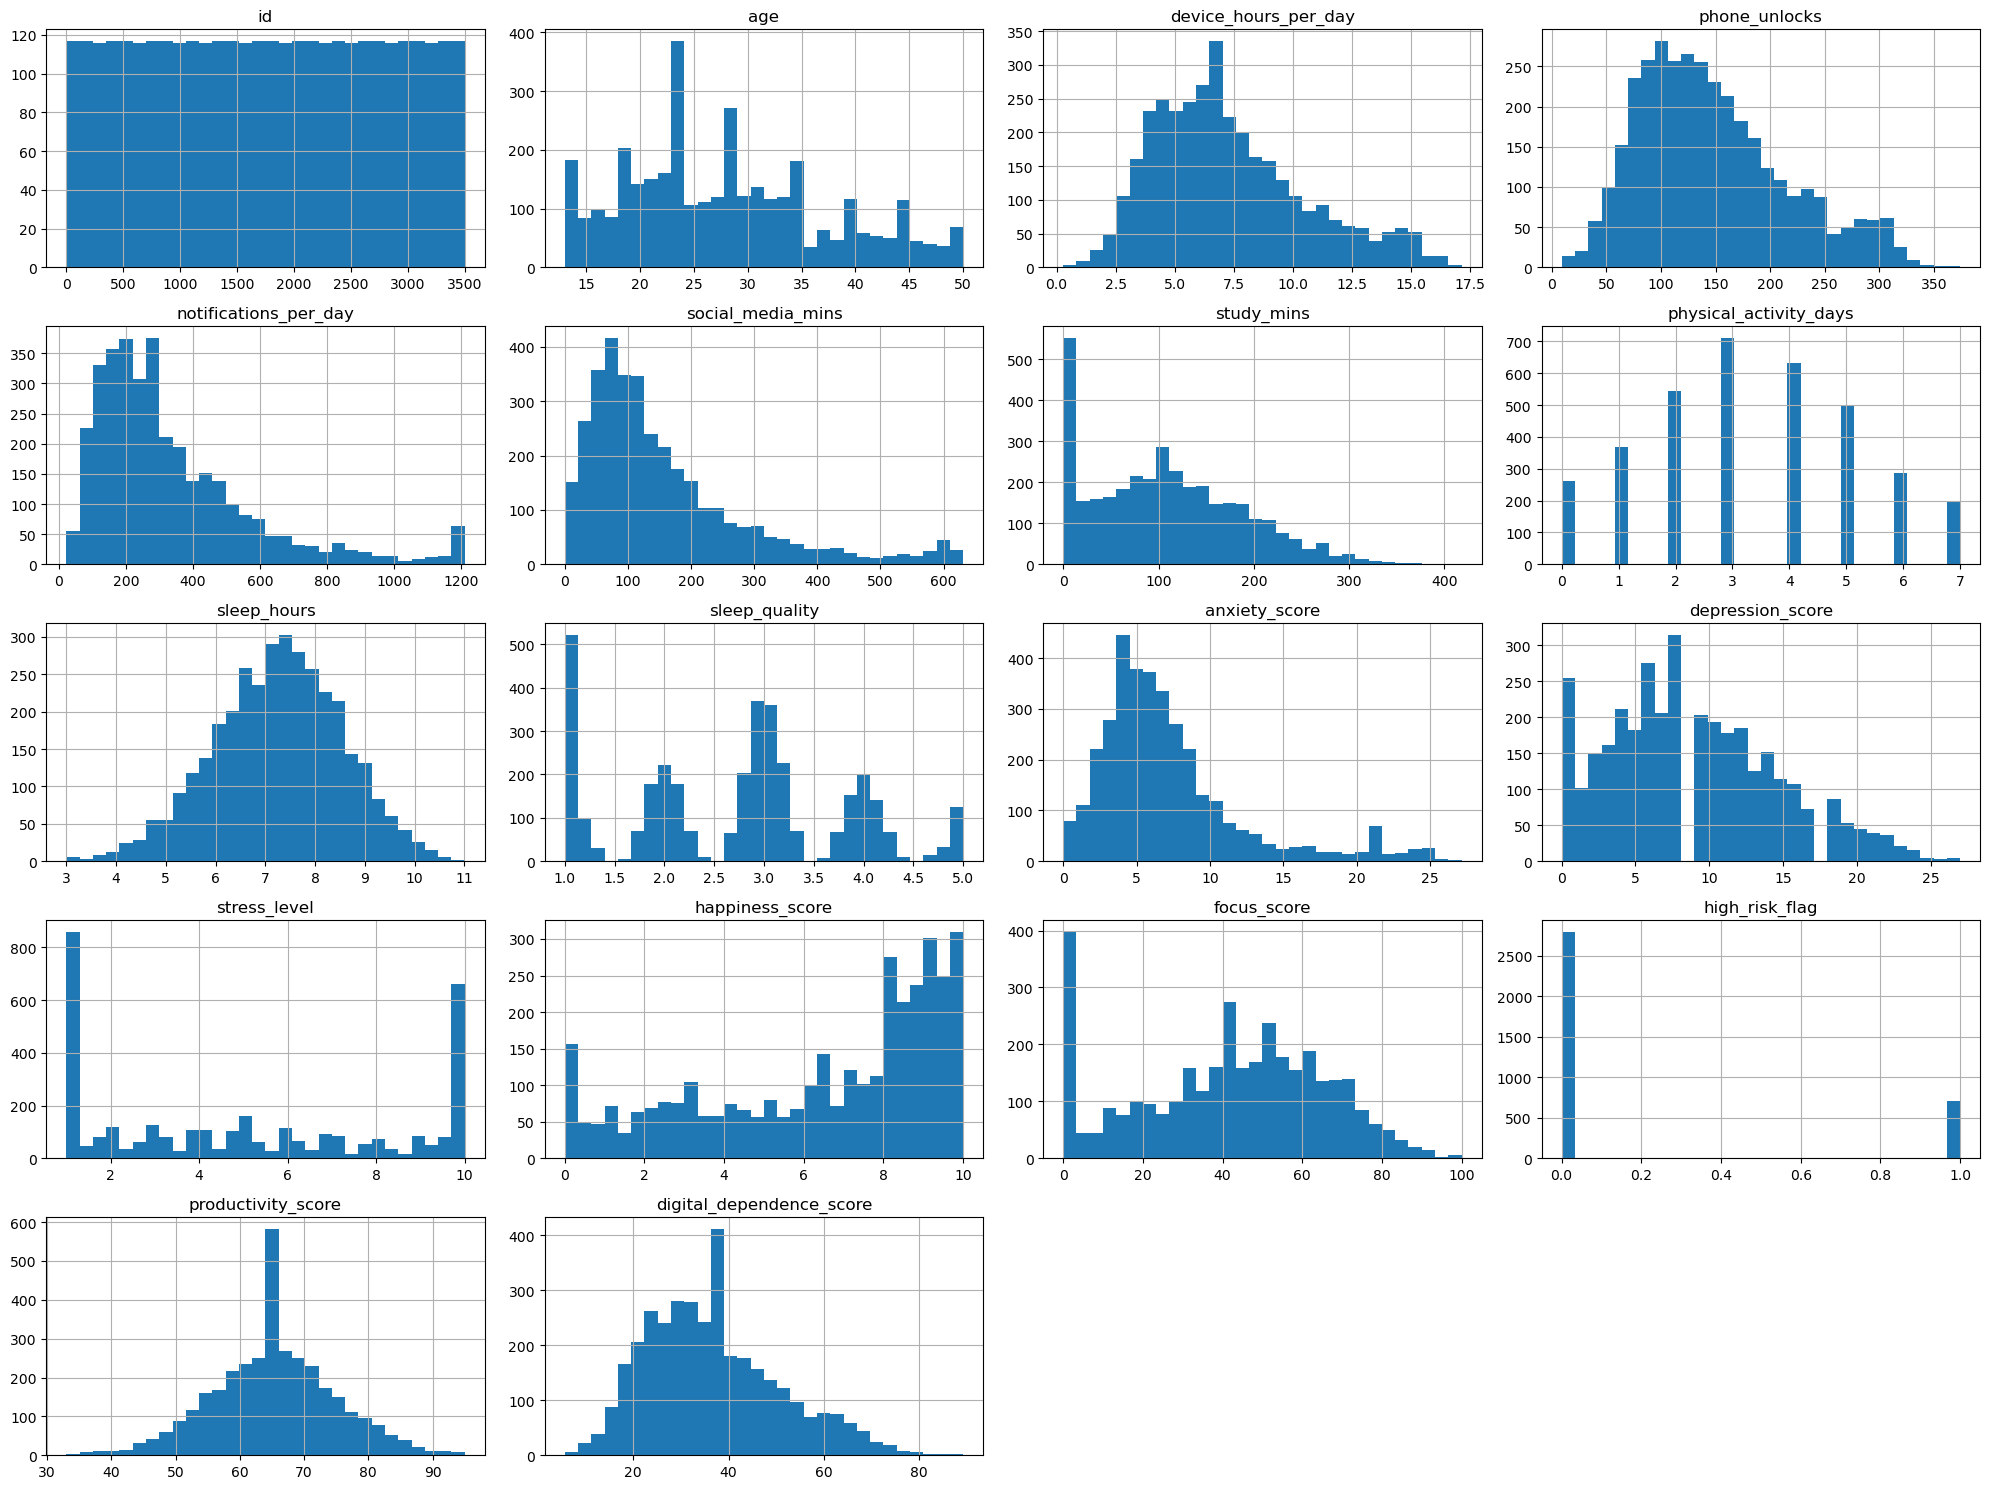

In [ ]:
df[continuous_cols].hist(figsize=(20,15), bins=30)
plt.tight_layout()
plt.show()

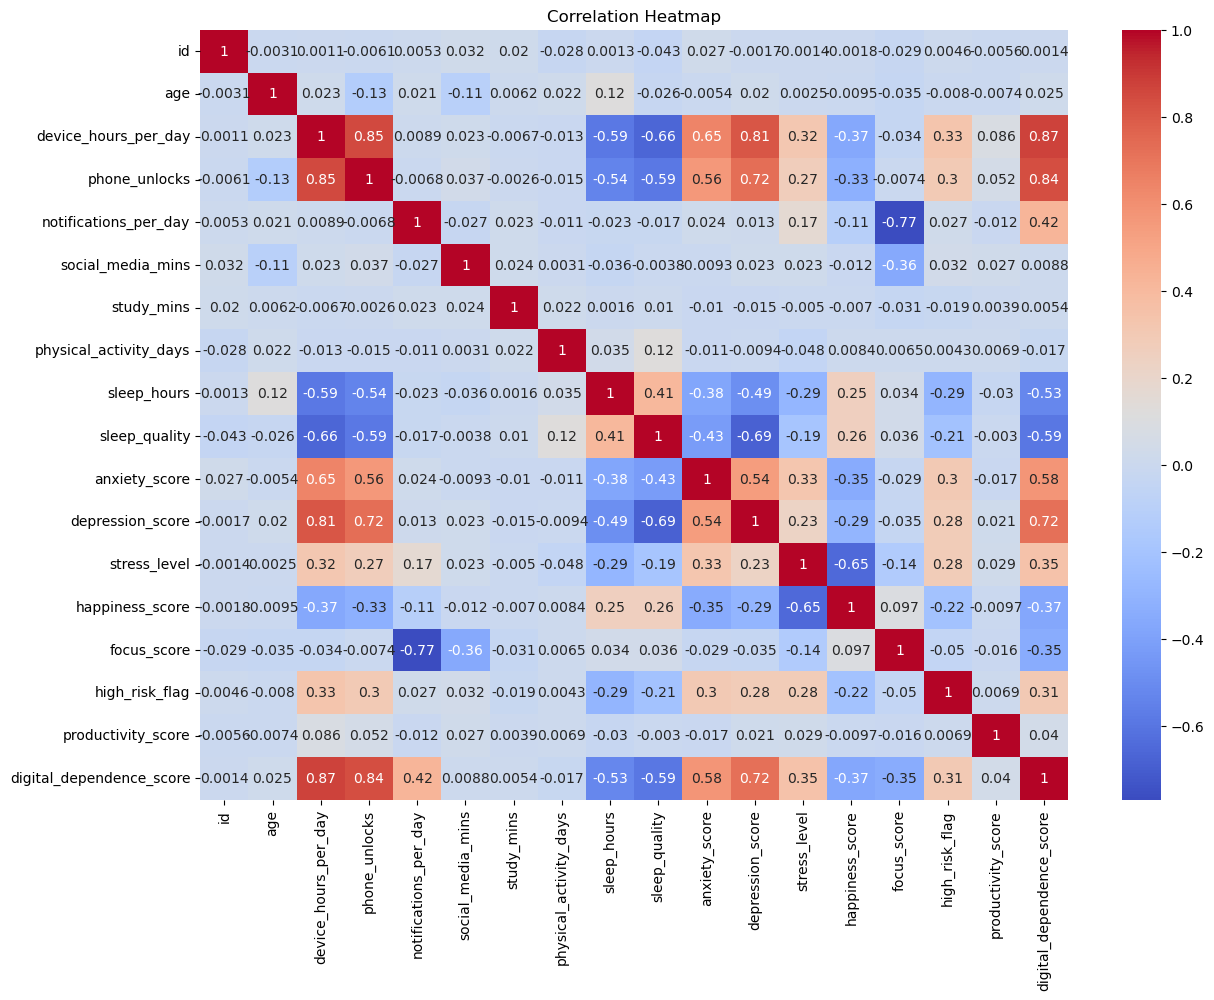

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(df[continuous_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

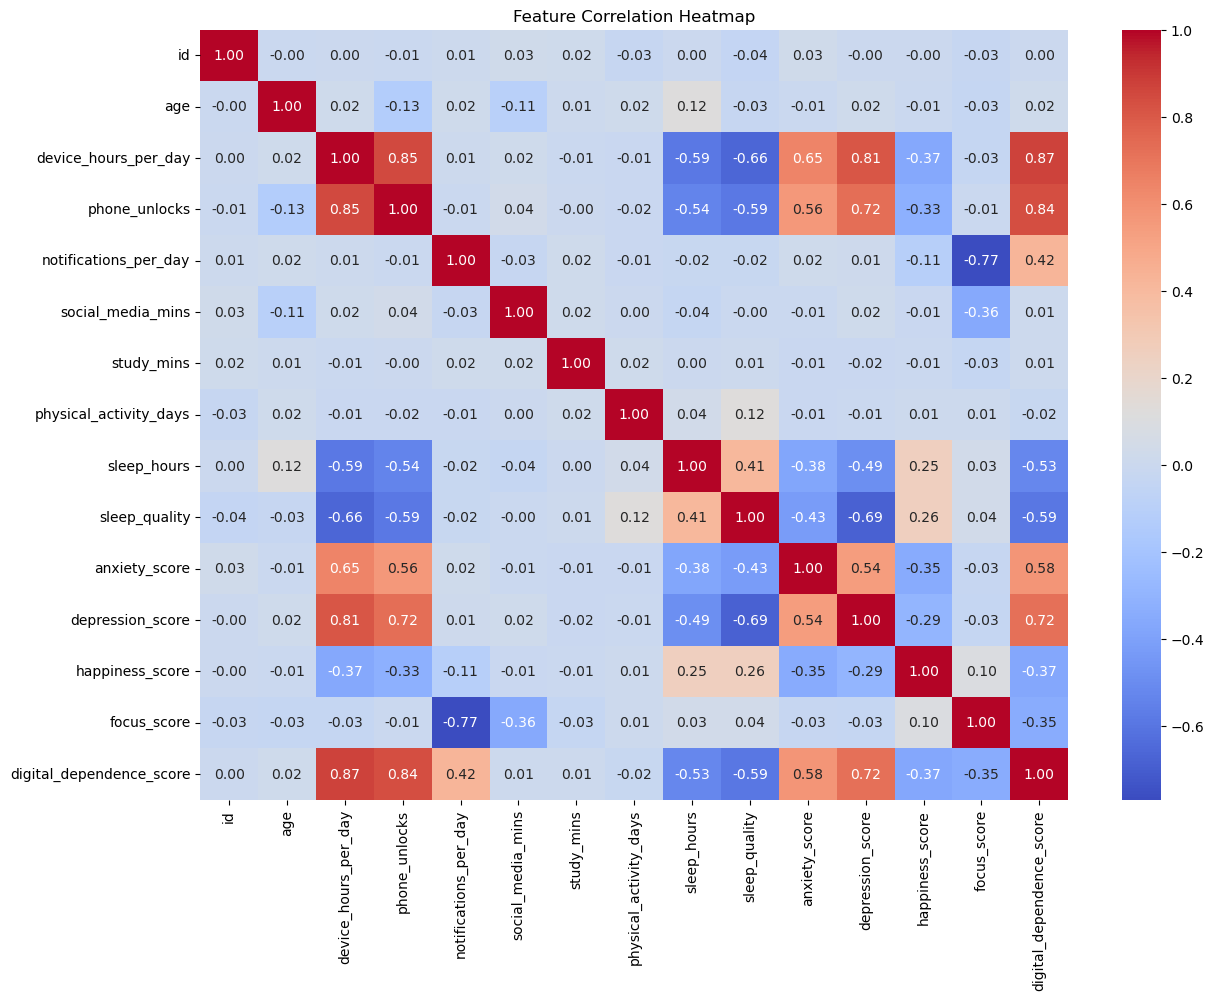

In [10]:
feature_cols = [col for col in continuous_cols
                if col not in ['high_risk_flag',
                               'stress_level',
                               'productivity_score']]

plt.figure(figsize=(14,10))
sns.heatmap(
    df[feature_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Feature Correlation Heatmap")
plt.show()

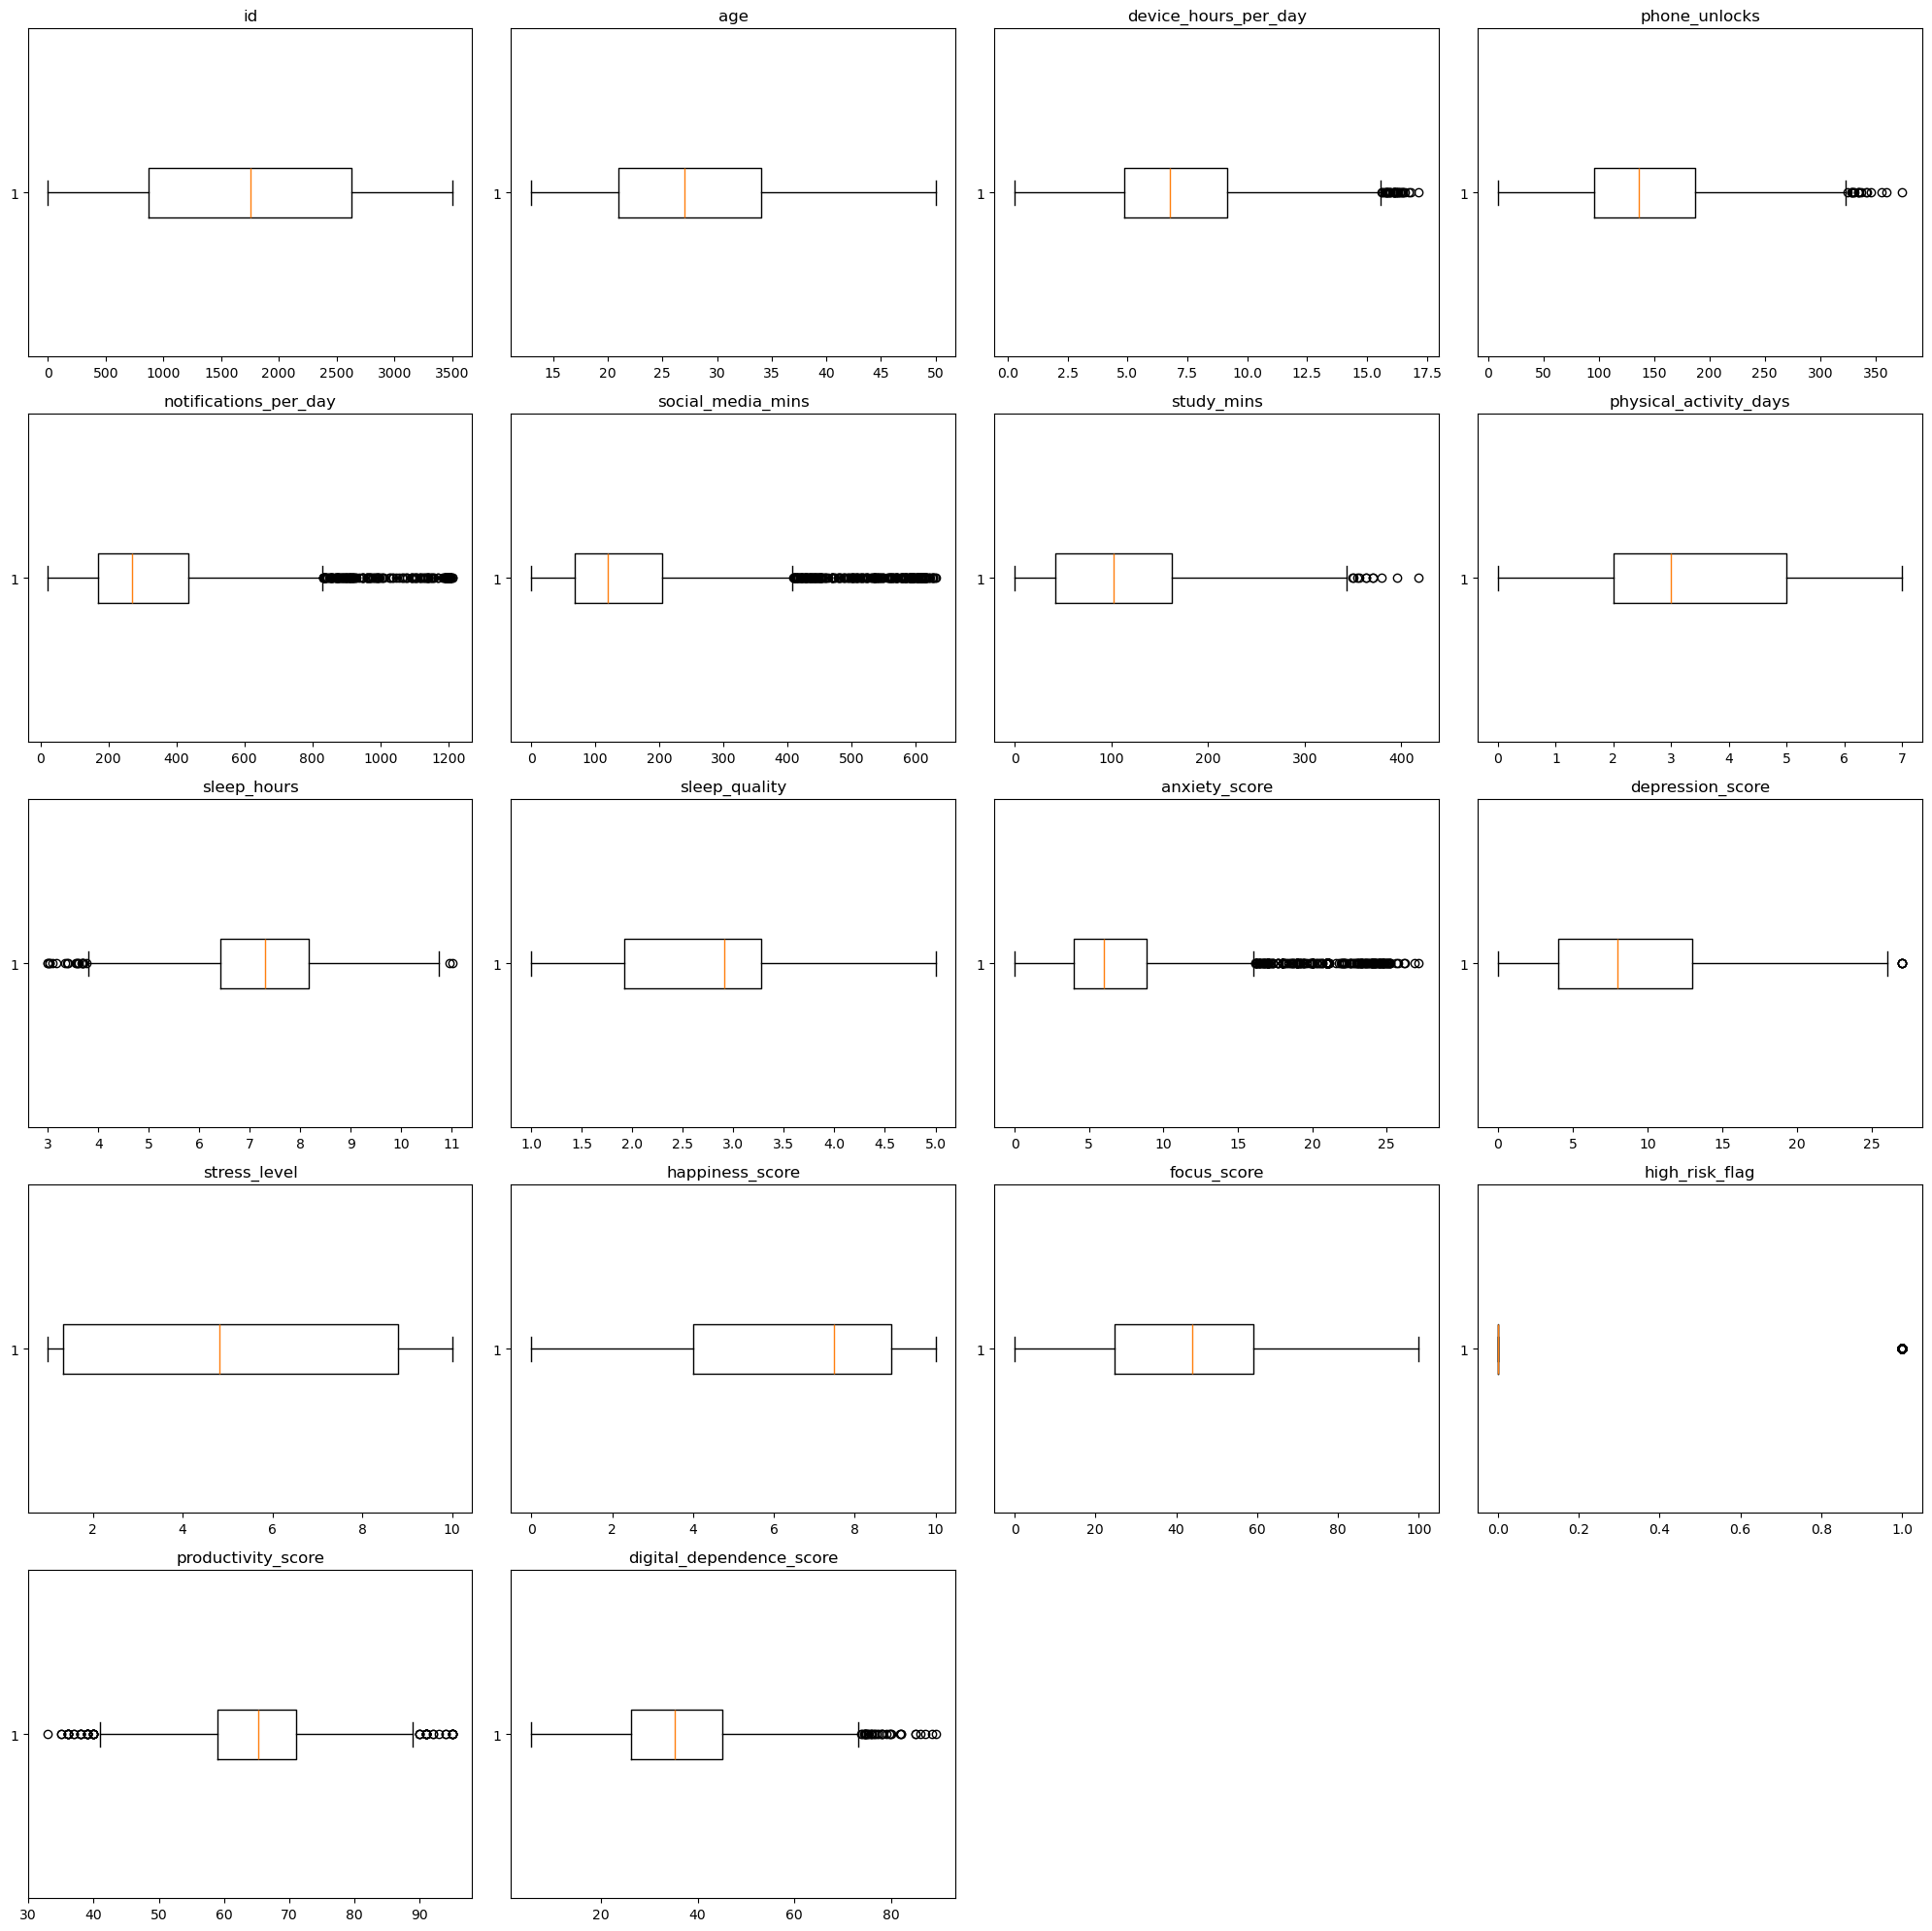

In [14]:
# Number of columns in the grid
n_cols = 4

# Calculate number of rows needed
n_rows = (len(continuous_cols) + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))

# Flatten axes for easier iteration
axes = axes.flatten()

# Loop through columns and plot
for i, col in enumerate(continuous_cols):
    axes[i].boxplot(df[col], vert=False)
    axes[i].set_title(col)

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [16]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


gender
gender
Female    1835
Male      1665
Name: count, dtype: int64

region
region
Europe           797
Asia             739
North America    622
Africa           578
South America    425
Middle East      339
Name: count, dtype: int64

income_level
income_level
Low          1139
Lower-Mid    1044
Upper-Mid     842
High          475
Name: count, dtype: int64

education_level
education_level
Bachelor       1573
High School    1103
Master          652
PhD             172
Name: count, dtype: int64

daily_role
daily_role
Full-time Employee    1429
Student                905
Part-time/Shift        659
Unemployed_Looking     358
Caregiver/Home         149
Name: count, dtype: int64

device_type
device_type
Android    903
Tablet     888
Laptop     886
iPhone     823
Name: count, dtype: int64


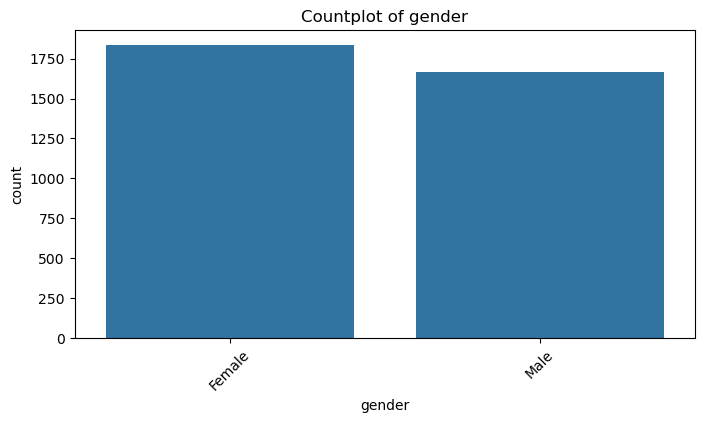

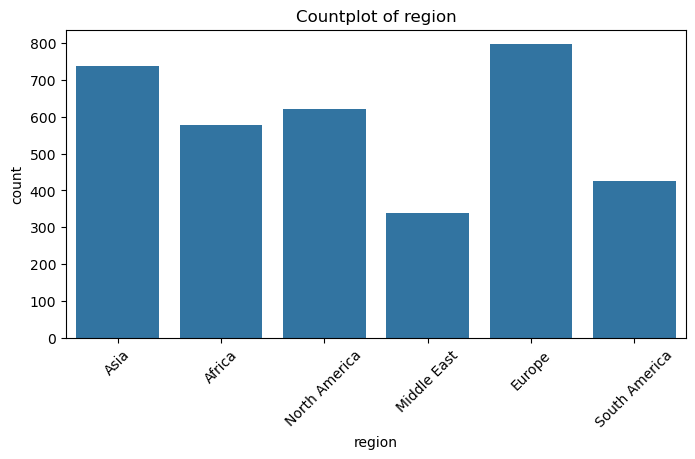

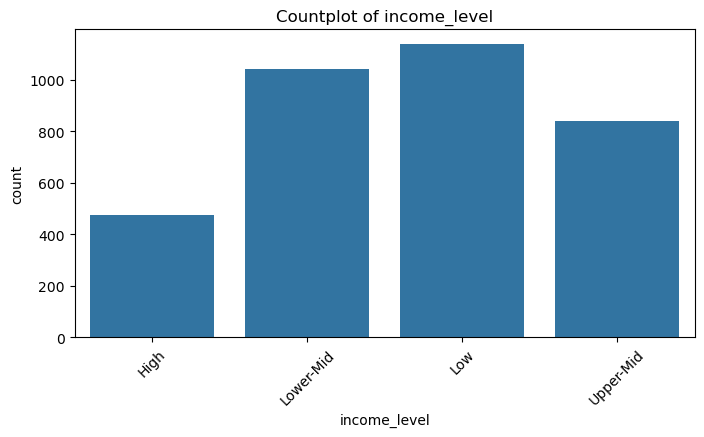

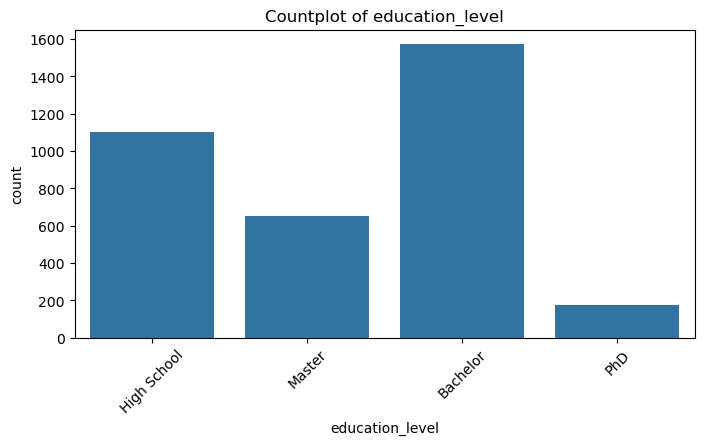

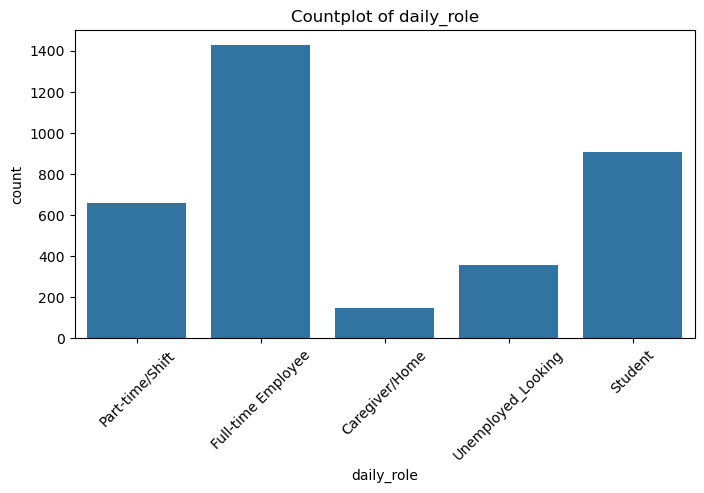

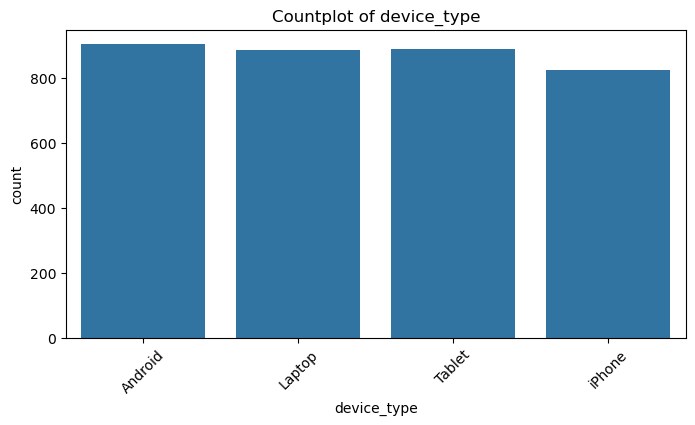

In [17]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(f"Countplot of {col}")
    plt.show()

# Machine Learning

# 1. target: high_risk_flag 
* Classificaiton

In [11]:
cols_drop_1 = ['high_risk_flag', 'productivity_score', 'digital_dependence_score']

In [12]:
X = df.drop(columns = cols_drop_1)
y = df['high_risk_flag']

In [17]:
X = pd.get_dummies(X, drop_first=False)

In [19]:
pd.set_option('display.max_columns', None)

In [21]:
print(X.dtypes)

id                                 int64
age                                int64
device_hours_per_day             float64
phone_unlocks                      int64
notifications_per_day              int64
social_media_mins                  int64
study_mins                         int64
physical_activity_days           float64
sleep_hours                      float64
sleep_quality                    float64
anxiety_score                    float64
depression_score                 float64
stress_level                     float64
happiness_score                  float64
focus_score                      float64
gender_Female                       bool
gender_Male                         bool
region_Africa                       bool
region_Asia                         bool
region_Europe                       bool
region_Middle East                  bool
region_North America                bool
region_South America                bool
income_level_High                   bool
income_level_Low

In [22]:
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [24]:
print(X.dtypes)

id                                 int64
age                                int64
device_hours_per_day             float64
phone_unlocks                      int64
notifications_per_day              int64
social_media_mins                  int64
study_mins                         int64
physical_activity_days           float64
sleep_hours                      float64
sleep_quality                    float64
anxiety_score                    float64
depression_score                 float64
stress_level                     float64
happiness_score                  float64
focus_score                      float64
gender_Female                      int64
gender_Male                        int64
region_Africa                      int64
region_Asia                        int64
region_Europe                      int64
region_Middle East                 int64
region_North America               int64
region_South America               int64
income_level_High                  int64
income_level_Low

In [23]:
X

,id,age,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,study_mins,physical_activity_days,sleep_hours,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,gender_Female,gender_Male,region_Africa,region_Asia,region_Europe,region_Middle East,region_North America,region_South America,income_level_High,income_level_Low,income_level_Lower-Mid,income_level_Upper-Mid,education_level_Bachelor,education_level_High School,education_level_Master,education_level_PhD,daily_role_Caregiver/Home,daily_role_Full-time Employee,daily_role_Part-time/Shift,daily_role_Student,daily_role_Unemployed_Looking,device_type_Android,device_type_Laptop,device_type_Tablet,device_type_iPhone
0,1,40,3.54,45,561,98,34,7.0,9.123800,3.353627,9.926651,5.0,6.593289,8.0,23.0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0
1,2,27,5.65,100,393,174,102,2.0,8.837517,2.908147,4.000000,4.0,4.126926,8.1,35.0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,1,0,0
2,3,31,8.87,181,231,595,140,1.0,6.486743,2.889213,4.000000,8.0,1.429139,7.6,15.0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0
3,4,41,4.05,94,268,18,121,4.0,7.600504,3.097488,7.093357,9.0,4.995512,7.8,28.0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0
4,5,26,13.07,199,91,147,60,1.0,5.197962,2.786098,7.028125,15.0,9.448757,4.2,70.0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,3496,15,6.41,119,308,111,11,3.0,6.128898,2.950001,4.772862,9.0,7.076726,2.4,59.0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0
3496,3497,28,4.21,55,415,136,155,4.0,6.699823,3.124953,5.520824,2.0,1.000000,8.9,27.0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0
3497,3498,44,11.51,146,119,41,206,6.0,6.590077,2.269790,8.518051,11.0,1.783568,7.6,56.0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,0
3498,3499,29,5.13,63,180,182,153,2.0,9.626066,4.902579,4.238655,8.0,10.000000,2.8,52.0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0


In [14]:
y

0       0
1       0
2       0
3       1
4       1
       ..
3495    0
3496    1
3497    0
3498    0
3499    0
Name: high_risk_flag, Length: 3500, dtype: int64

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Baseline models (LogisticRegression and KNN)
## Scaling 

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## LogisticRegression

In [27]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
y_train_pred = model.predict(X_train_scaled)

# Training
y_train_pred = model.predict(X_train_scaled)
print("TRAINING RESULTS")
print()
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print()
print(classification_report(y_train, y_train_pred))

# Testing 
y_test_pred = model.predict(X_test_scaled)
print("TESTING RESULTS")
print()
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print()
print(classification_report(y_test, y_test_pred))

# ROC-AUC Score
y_test_prob = model.predict_proba(X_test_scaled)[:,1]
roc_auc = roc_auc_score(y_test, y_test_prob)
print("ROC-AUC Score:", roc_auc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

TRAINING RESULTS

Accuracy: 0.8382142857142857

              precision    recall  f1-score   support

           0       0.85      0.97      0.91      2236
           1       0.73      0.31      0.44       564

    accuracy                           0.84      2800
   macro avg       0.79      0.64      0.67      2800
weighted avg       0.82      0.84      0.81      2800

TESTING RESULTS

Accuracy: 0.8414285714285714

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       559
           1       0.77      0.30      0.44       141

    accuracy                           0.84       700
   macro avg       0.81      0.64      0.67       700
weighted avg       0.83      0.84      0.81       700

ROC-AUC Score: 0.7440211116608939
Confusion Matrix:
[[546  13]
 [ 98  43]]


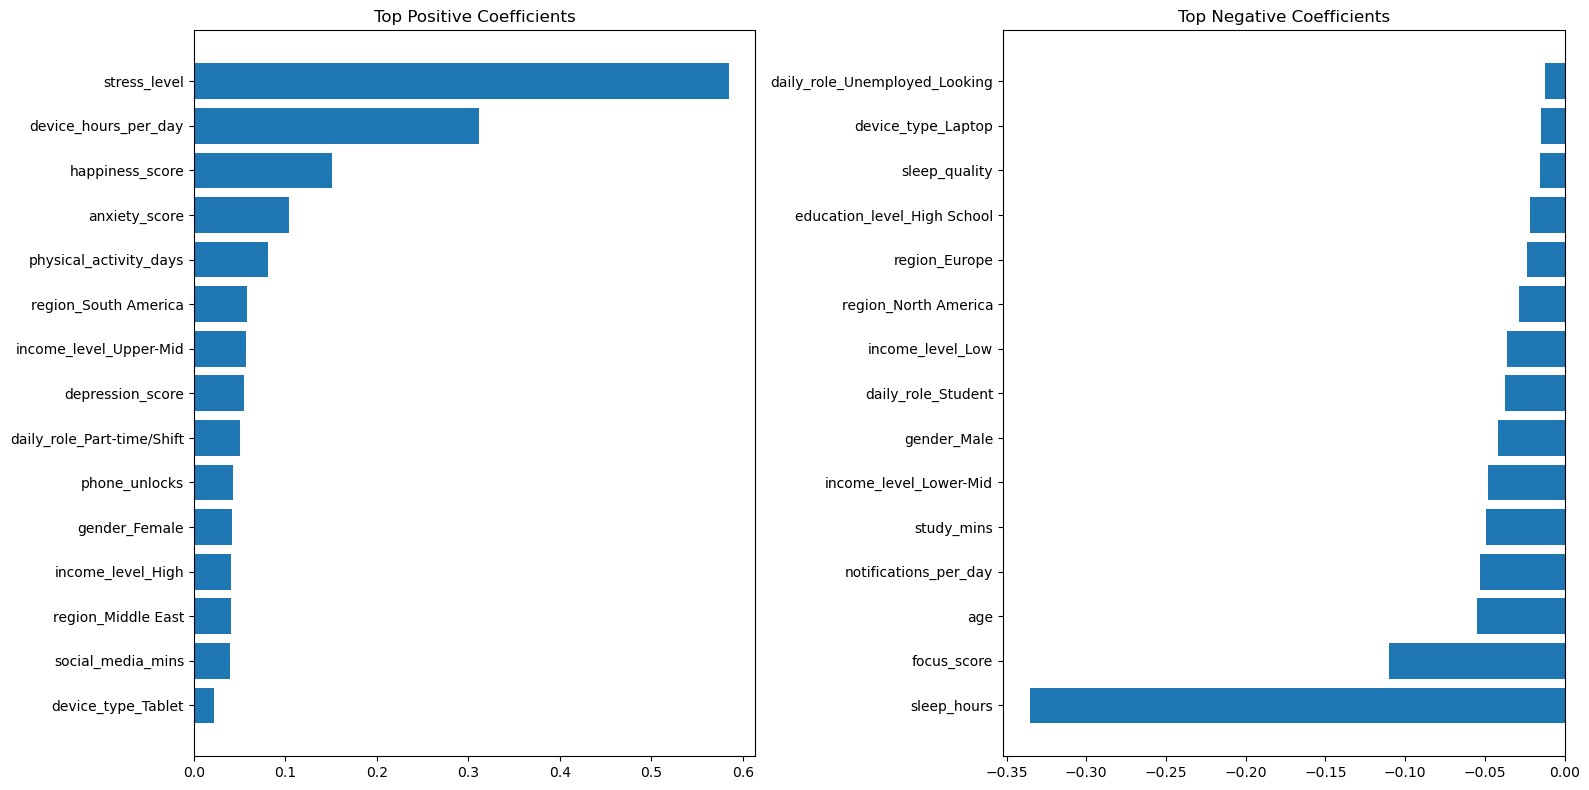

In [ ]:
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model.coef_[0]})
coef_df = coef_df.sort_values(by = 'Coefficient')
top_positive = coef_df.nlargest(15, 'Coefficient')
top_negative = coef_df.nsmallest(15, 'Coefficient')
fig, axes = plt.subplots(1, 2, figsize = (16, 8))
axes[0].barh(top_positive['Feature'][::-1],top_positive['Coefficient'][::-1])
axes[0].set_title("Top Positive Coefficients")
axes[1].barh(top_negative['Feature'], top_negative['Coefficient'])
axes[1].set_title("Top Negative Coefficients")
plt.tight_layout()
plt.show()

# KNN

In [28]:
knn_model = KNeighborsClassifier(n_neighbors = 5, weights = 'uniform', metric = 'minkowski')
knn_model.fit(X_train_scaled, y_train)

# Training
y_train_pred = knn_model.predict(X_train_scaled)
print("TRAINING RESULTS")
print()
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print()
print(classification_report(y_train, y_train_pred))

# Testing
y_test_pred = knn_model.predict(X_test_scaled)
print("TESTING RESULTS")
print()
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print()
print(classification_report(y_test, y_test_pred))

# ROC-AUC Score
y_test_prob = knn_model.predict_proba(X_test_scaled)[:,1]
roc_auc = roc_auc_score(y_test, y_test_prob)
print("ROC-AUC Score:", roc_auc)

# Confusion Matrix 
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)


TRAINING RESULTS

Accuracy: 0.8475

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      2236
           1       0.79      0.33      0.47       564

    accuracy                           0.85      2800
   macro avg       0.82      0.66      0.69      2800
weighted avg       0.84      0.85      0.82      2800

TESTING RESULTS

Accuracy: 0.8142857142857143

              precision    recall  f1-score   support

           0       0.83      0.96      0.89       559
           1       0.60      0.23      0.33       141

    accuracy                           0.81       700
   macro avg       0.72      0.59      0.61       700
weighted avg       0.79      0.81      0.78       700

ROC-AUC Score: 0.6782628554028851
Confusion Matrix:
[[538  21]
 [109  32]]


# XGBoosting

In [31]:
xgb = XGBClassifier(
    random_state = 42,
    eval_metric = 'logloss'
)

param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 4, 6],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,
    cv=8,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)
print("Best parameters:")
print(random_search.best_params_)

best_xgb = random_search.best_estimator_
y_pred = best_xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Fitting 8 folds for each of 40 candidates, totalling 320 fits
Best parameters:
{'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
Accuracy: 0.8771428571428571
              precision    recall  f1-score   support

           0       0.89      0.96      0.93       559
           1       0.79      0.53      0.64       141

    accuracy                           0.88       700
   macro avg       0.84      0.75      0.78       700
weighted avg       0.87      0.88      0.87       700



TRAINING RESULTS

Accuracy: 0.8842857142857142

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      2236
           1       0.83      0.54      0.65       564

    accuracy                           0.88      2800
   macro avg       0.86      0.76      0.79      2800
weighted avg       0.88      0.88      0.87      2800

TESTING RESULTS

Accuracy: 0.8771428571428571

              precision    recall  f1-score   support

           0       0.89      0.96      0.93       559
           1       0.79      0.53      0.64       141

    accuracy                           0.88       700
   macro avg       0.84      0.75      0.78       700
weighted avg       0.87      0.88      0.87       700

ROC-AUC Score: 0.7779342544310384
Confusion Matrix:
[[539  20]
 [ 66  75]]


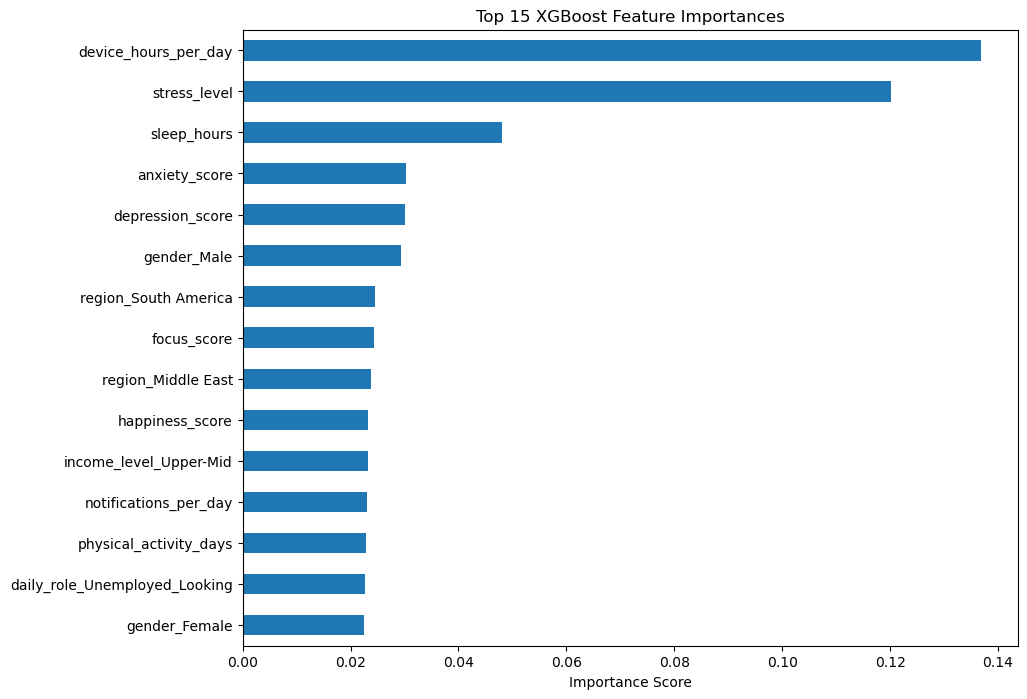

In [32]:
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.9,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
y_train_pred = xgb_model.predict(X_train)

# Training
print("TRAINING RESULTS")
print()
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print()
print(classification_report(y_train, y_train_pred))

#Testing
y_test_pred = xgb_model.predict(X_test)
print("TESTING RESULTS")
print()
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print()
print(classification_report(y_test, y_test_pred))

y_test_prob = xgb_model.predict_proba(X_test)[:,1]

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_test_prob)
print("ROC-AUC Score:", roc_auc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(10,8))
importance.tail(15).plot(kind='barh')
plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance Score")
plt.show()

# ADABoost 

In [39]:
ada = AdaBoostClassifier(
    estimator = DecisionTreeClassifier(random_state=42),
    random_state = 42
)

param_dist_ada = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.3, 1.0],
    'estimator__max_depth': [1, 2, 3, 4],
    'estimator__min_samples_split': [2, 5, 10]
}

random_search_ada = RandomizedSearchCV(
    estimator=ada,
    param_distributions=param_dist_ada,
    n_iter=20,
    cv=10,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search_ada.fit(X_train, y_train)

print("Best parameters:")
print(random_search_ada.best_params_)
best_ada = random_search_ada.best_estimator_
y_pred = best_ada.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best parameters:
{'n_estimators': 300, 'learning_rate': 0.01, 'estimator__min_samples_split': 5, 'estimator__max_depth': 3}
Accuracy: 0.8785714285714286
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       559
           1       0.78      0.55      0.65       141

    accuracy                           0.88       700
   macro avg       0.84      0.76      0.79       700
weighted avg       0.87      0.88      0.87       700



TRAINING RESULTS

Accuracy: 0.8796428571428572

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      2236
           1       0.80      0.54      0.64       564

    accuracy                           0.88      2800
   macro avg       0.85      0.75      0.79      2800
weighted avg       0.87      0.88      0.87      2800

TESTING RESULTS

Accuracy: 0.8785714285714286

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       559
           1       0.78      0.55      0.65       141

    accuracy                           0.88       700
   macro avg       0.84      0.76      0.79       700
weighted avg       0.87      0.88      0.87       700

ROC-AUC Score: 0.7512972760375035
Confusion Matrix:
[[537  22]
 [ 63  78]]


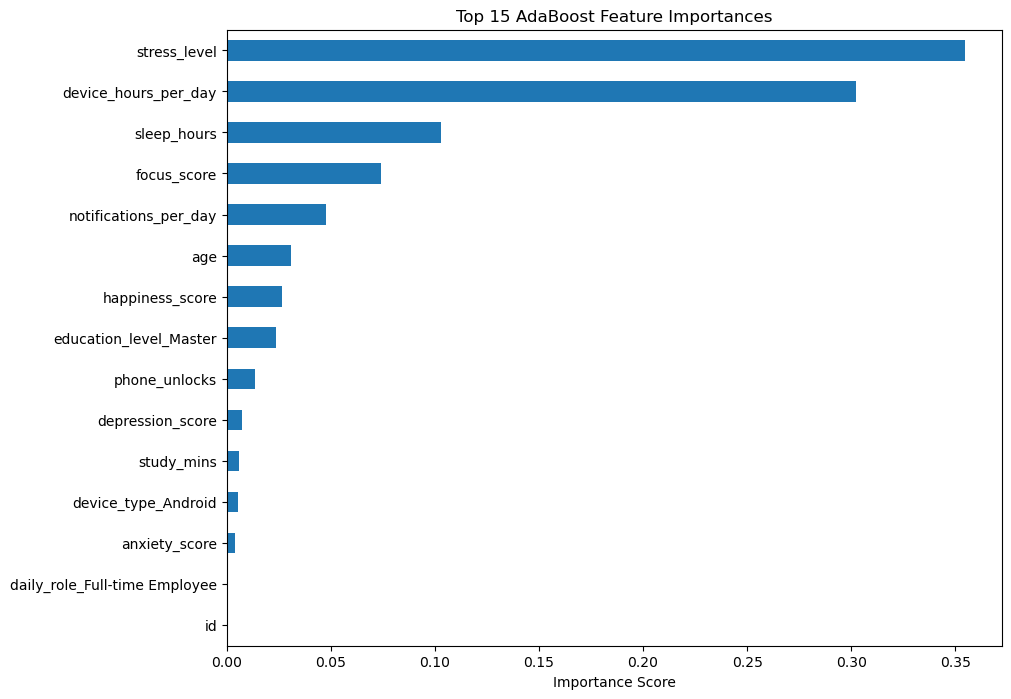

In [40]:
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=3,
        min_samples_split=5,
        random_state=42
    ),
    n_estimators=300,
    learning_rate=0.01,
    random_state=42
)

ada_model.fit(X_train, y_train)
y_train_pred = ada_model.predict(X_train)

# Training
print("TRAINING RESULTS")
print()
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print()
print(classification_report(y_train, y_train_pred))

#Testing
y_test_pred = ada_model.predict(X_test)
print("TESTING RESULTS")
print()
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print()
print(classification_report(y_test, y_test_pred))

y_test_prob = ada_model.predict_proba(X_test)[:,1]

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_test_prob)
print("ROC-AUC Score:", roc_auc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

importance = pd.Series(
    ada_model.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(10,8))
importance.tail(15).plot(kind='barh')
plt.title("Top 15 AdaBoost Feature Importances")
plt.xlabel("Importance Score")
plt.show()

# GradientBoosting

In [41]:
gb = GradientBoostingClassifier(random_state=42)
param_dist_gb = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

random_search_gb = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist_gb,
    n_iter=40,
    cv=8,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search_gb.fit(X_train, y_train)
print("Best Gradient Boosting Parameters:")
print(random_search_gb.best_params_)
best_gb = random_search_gb.best_estimator_

Fitting 8 folds for each of 40 candidates, totalling 320 fits
Best Gradient Boosting Parameters:
{'subsample': 0.7, 'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 3, 'learning_rate': 0.01}


TRAINING RESULTS

Accuracy: 0.8871428571428571

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      2236
           1       0.84      0.54      0.66       564

    accuracy                           0.89      2800
   macro avg       0.87      0.76      0.80      2800
weighted avg       0.88      0.89      0.88      2800

TESTING RESULTS

Accuracy: 0.8828571428571429

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       559
           1       0.82      0.54      0.65       141

    accuracy                           0.88       700
   macro avg       0.86      0.75      0.79       700
weighted avg       0.88      0.88      0.87       700

ROC-AUC Score: 0.7657290754767251
Confusion Matrix:
[[542  17]
 [ 65  76]]
stress_level                     0.385635
device_hours_per_day             0.321493
sleep_hours                      0.083265
notifications_per_day            0.028722
anxiety_

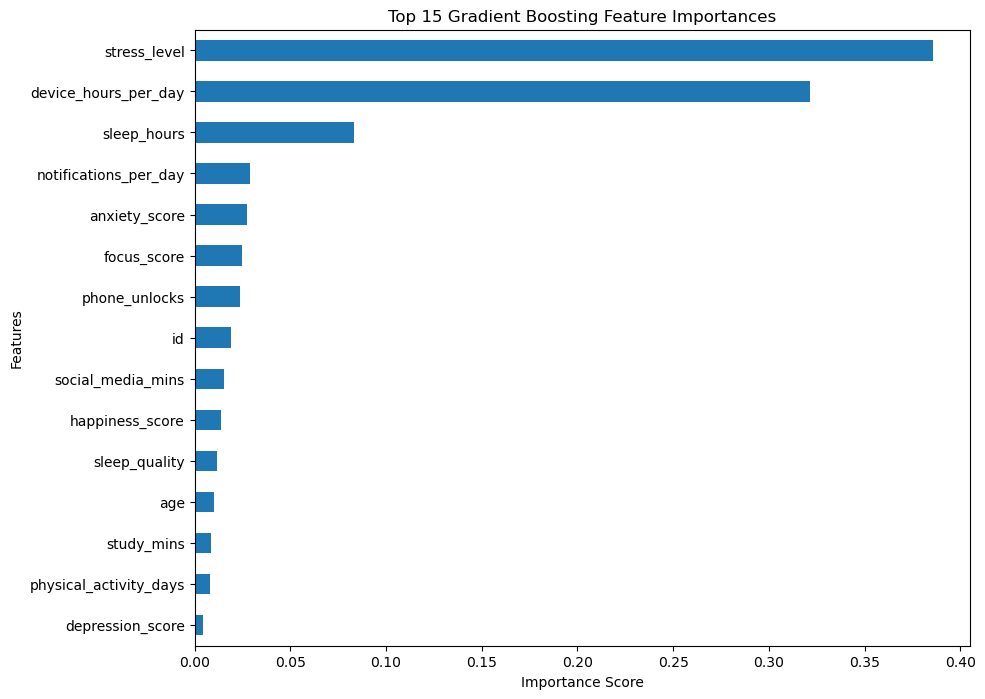

In [42]:
gb_model = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=4,
    subsample=0.7,
    max_features=None,
    random_state=42
)

gb_model.fit(X_train, y_train)
y_train_pred = gb_model.predict(X_train)
print("TRAINING RESULTS")
print()
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print()
print(classification_report(y_train, y_train_pred))
y_test_pred = gb_model.predict(X_test)

print("TESTING RESULTS")
print()
print("Accuracy:",accuracy_score(y_test, y_test_pred))
print()
print(classification_report(y_test, y_test_pred))

# ROC-AUC score
y_test_prob = gb_model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_test_prob)
print("ROC-AUC Score:", roc_auc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

importance_gb = pd.Series(
    gb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance_gb)
plt.figure(figsize=(10,8))
importance_gb.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 Gradient Boosting Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# Random Forest 

In [33]:
rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,
    cv=8,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search_rf.fit(X_train, y_train)
print("Best Parameters:")
print(random_search_rf.best_params_)
best_rf = random_search_rf.best_estimator_

Fitting 8 folds for each of 40 candidates, totalling 320 fits
Best Parameters:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}


TRAINING RESULTS

Accuracy: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2236
           1       1.00      1.00      1.00       564

    accuracy                           1.00      2800
   macro avg       1.00      1.00      1.00      2800
weighted avg       1.00      1.00      1.00      2800

TESTING RESULTS

Accuracy: 0.8771428571428571

              precision    recall  f1-score   support

           0       0.88      0.97      0.93       559
           1       0.82      0.50      0.62       141

    accuracy                           0.88       700
   macro avg       0.85      0.73      0.77       700
weighted avg       0.87      0.88      0.86       700

ROC-AUC Score: 0.7837894416320937
Confusion Matrix:
[[544  15]
 [ 71  70]]
stress_level                     0.146373
device_hours_per_day             0.117985
sleep_hours                      0.093519
phone_unlocks                    0.065526
anxiety_score          

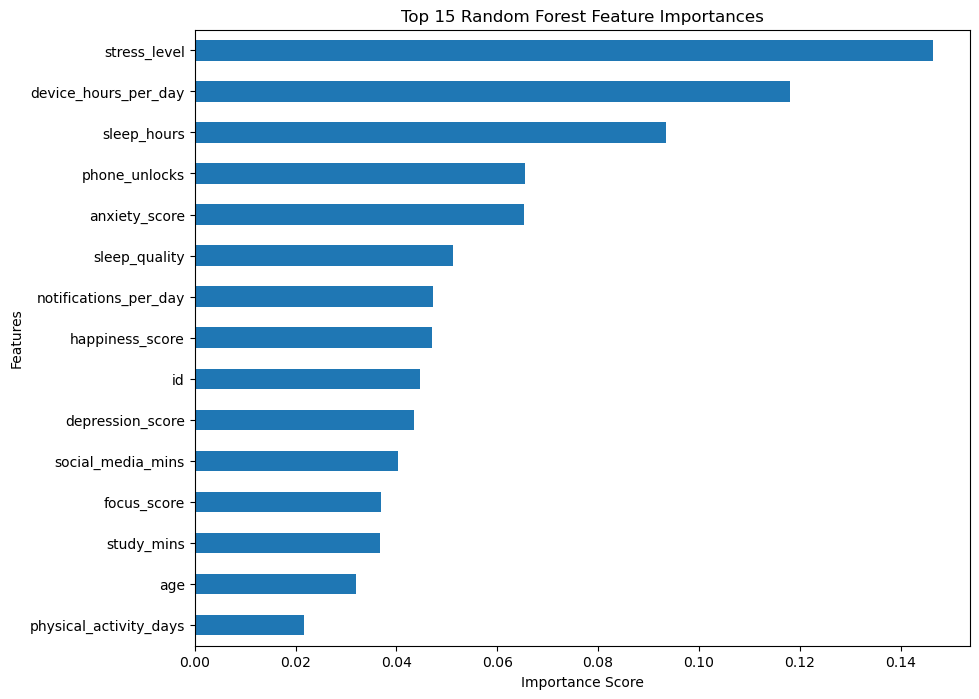

In [34]:
rf_model = RandomForestClassifier(
    n_estimators = 500,
    min_samples_split = 5,
    min_samples_leaf = 1,
    max_features = 'sqrt',
    max_depth = None,
    bootstrap = False,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_train_pred = rf_model.predict(X_train)
print("TRAINING RESULTS")
print()
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print()
print(classification_report(y_train, y_train_pred))
y_test_pred = rf_model.predict(X_test)

print("TESTING RESULTS")
print()
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print()
print(classification_report(y_test, y_test_pred))
y_test_prob = rf_model.predict_proba(X_test)[:,1]

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_test_prob)
print("ROC-AUC Score:", roc_auc)
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance_rf)
plt.figure(figsize=(10,8))
importance_rf.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# 2. target: productivity_score
* Regression

In [55]:
df

,id,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,study_mins,physical_activity_days,sleep_hours,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score
0,1,40,Female,Asia,High,High School,Part-time/Shift,3.54,45,561,98,34,7.0,9.123800,3.353627,9.926651,5.0,6.593289,8.0,23.0,0,Android,70.000000,25.700000
1,2,27,Male,Africa,Lower-Mid,Master,Full-time Employee,5.65,100,393,174,102,2.0,8.837517,2.908147,4.000000,4.0,4.126926,8.1,35.0,0,Laptop,64.000000,30.100000
2,3,31,Male,North America,Lower-Mid,Bachelor,Full-time Employee,8.87,181,231,595,140,1.0,6.486743,2.889213,4.000000,8.0,1.429139,7.6,15.0,0,Android,65.299301,40.600000
3,4,41,Female,Middle East,Low,Master,Caregiver/Home,4.05,94,268,18,121,4.0,7.600504,3.097488,7.093357,9.0,4.995512,7.8,28.0,1,Tablet,80.000000,36.684152
4,5,26,Female,Europe,Lower-Mid,Bachelor,Full-time Employee,13.07,199,91,147,60,1.0,5.197962,2.786098,7.028125,15.0,9.448757,4.2,70.0,1,Android,65.299301,48.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,3496,15,Female,Africa,Low,High School,Part-time/Shift,6.41,119,308,111,11,3.0,6.128898,2.950001,4.772862,9.0,7.076726,2.4,59.0,0,Laptop,84.000000,29.600000
3496,3497,28,Female,Europe,High,Bachelor,Part-time/Shift,4.21,55,415,136,155,4.0,6.699823,3.124953,5.520824,2.0,1.000000,8.9,27.0,1,Laptop,73.000000,23.200000
3497,3498,44,Female,Europe,Lower-Mid,Bachelor,Part-time/Shift,11.51,146,119,41,206,6.0,6.590077,2.269790,8.518051,11.0,1.783568,7.6,56.0,0,Android,65.000000,42.400000
3498,3499,29,Female,North America,Low,Master,Full-time Employee,5.13,63,180,182,153,2.0,9.626066,4.902579,4.238655,8.0,10.000000,2.8,52.0,0,Laptop,63.000000,20.500000


In [56]:
cols_drop_2 = ['high_risk_flag', 'productivity_score', 'digital_dependence_score']
X = df.drop(columns = cols_drop_2)
y = df['productivity_score']

In [57]:
X = pd.get_dummies(X, drop_first=False)
print(X.dtypes)

id                                 int64
age                                int64
device_hours_per_day             float64
phone_unlocks                      int64
notifications_per_day              int64
social_media_mins                  int64
study_mins                         int64
physical_activity_days           float64
sleep_hours                      float64
sleep_quality                    float64
anxiety_score                    float64
depression_score                 float64
stress_level                     float64
happiness_score                  float64
focus_score                      float64
gender_Female                       bool
gender_Male                         bool
region_Africa                       bool
region_Asia                         bool
region_Europe                       bool
region_Middle East                  bool
region_North America                bool
region_South America                bool
income_level_High                   bool
income_level_Low

In [58]:
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)
print(X.dtypes)

id                                 int64
age                                int64
device_hours_per_day             float64
phone_unlocks                      int64
notifications_per_day              int64
social_media_mins                  int64
study_mins                         int64
physical_activity_days           float64
sleep_hours                      float64
sleep_quality                    float64
anxiety_score                    float64
depression_score                 float64
stress_level                     float64
happiness_score                  float64
focus_score                      float64
gender_Female                      int64
gender_Male                        int64
region_Africa                      int64
region_Asia                        int64
region_Europe                      int64
region_Middle East                 int64
region_North America               int64
region_South America               int64
income_level_High                  int64
income_level_Low

In [59]:
y

0       70.000000
1       64.000000
2       65.299301
3       80.000000
4       65.299301
          ...    
3495    84.000000
3496    73.000000
3497    65.000000
3498    63.000000
3499    61.000000
Name: productivity_score, Length: 3500, dtype: float64

# Baseline models (Linear Regression and KNN)

## Scaling 

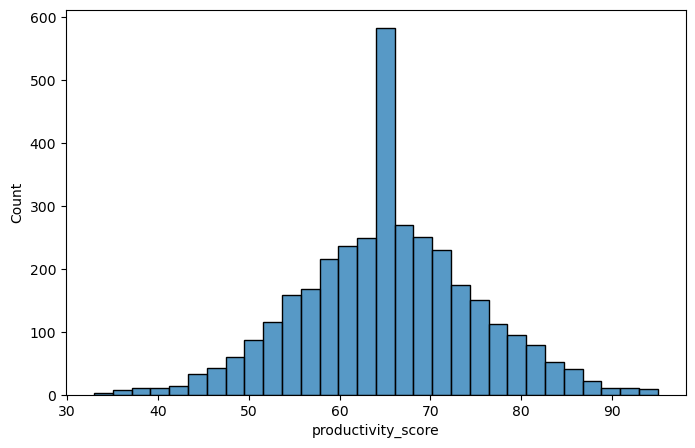

In [64]:
df['productivity_score'].describe()
plt.figure(figsize=(8,5))
sns.histplot(df['productivity_score'], bins=30)
plt.show()

In [65]:
corr_prod = (
    df.corr(numeric_only=True)['productivity_score']
    .sort_values(ascending=False)
)

print(corr_prod)

productivity_score          1.000000
device_hours_per_day        0.086328
phone_unlocks               0.051577
digital_dependence_score    0.039561
stress_level                0.029036
social_media_mins           0.027228
depression_score            0.020605
physical_activity_days      0.006899
high_risk_flag              0.006867
study_mins                  0.003876
sleep_quality              -0.002984
id                         -0.005571
age                        -0.007434
happiness_score            -0.009691
notifications_per_day      -0.012474
focus_score                -0.016047
anxiety_score              -0.016681
sleep_hours                -0.030029
Name: productivity_score, dtype: float64


In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [61]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

y_train_pred = linreg.predict(X_train_scaled)
y_test_pred = linreg.predict(X_test_scaled)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print()
print("TRAINING RESULTS")
print()
print(f"MAE : {train_mae:.4f}")
print(f"MSE : {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"R²  : {train_r2:.4f}")

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print()
print("TESTING RESULTS")
print()
print(f"MAE : {test_mae:.4f}")
print(f"MSE : {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²  : {test_r2:.4f}")


TRAINING RESULTS

MAE : 7.5149
MSE : 91.9597
RMSE: 9.5896
R²  : 0.0403

TESTING RESULTS

MAE : 7.1443
MSE : 84.6429
RMSE: 9.2002
R²  : -0.0140


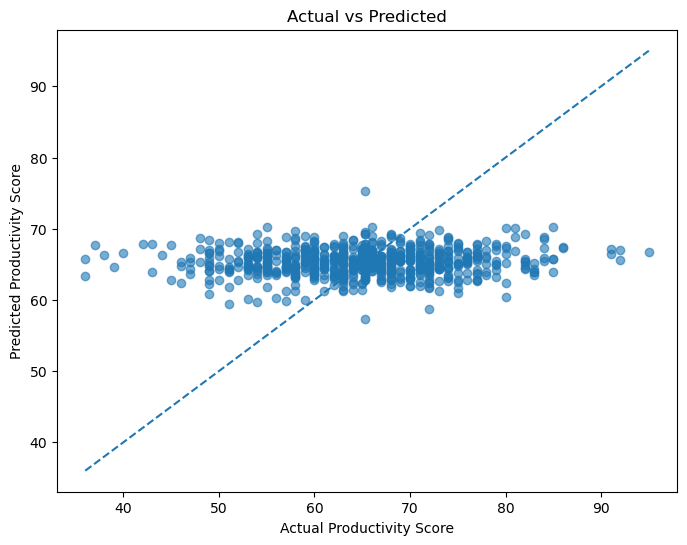

In [63]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_test_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    '--'
)

plt.xlabel("Actual Productivity Score")
plt.ylabel("Predicted Productivity Score")
plt.title("Actual vs Predicted")
plt.show()

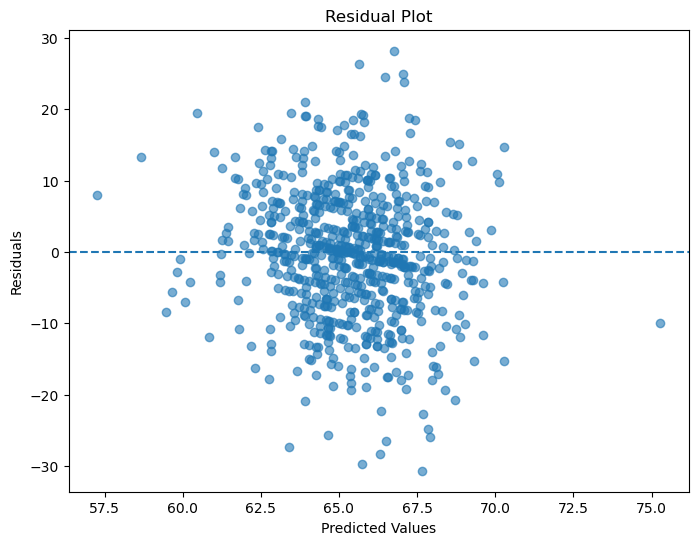

In [52]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8,6))
plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [53]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': linreg.coef_
})

coef_df = coef_df.sort_values(
    by='Coefficient'
)

print(coef_df)

                          Feature  Coefficient
10                  anxiety_score    -1.440984
11               depression_score    -1.023798
14                    focus_score    -0.720203
4           notifications_per_day    -0.667971
3                   phone_unlocks    -0.641603
1                             age    -0.398215
24               income_level_Low    -0.254309
34             daily_role_Student    -0.177627
18                    region_Asia    -0.169797
0                              id    -0.111509
16                    gender_Male    -0.084173
27       education_level_Bachelor    -0.075691
17                  region_Africa    -0.069611
23              income_level_High    -0.062314
37             device_type_Laptop    -0.041911
22           region_South America    -0.035317
20             region_Middle East    -0.033318
33     daily_role_Part-time/Shift    -0.026225
30            education_level_PhD    -0.018383
38             device_type_Tablet    -0.017070
36           

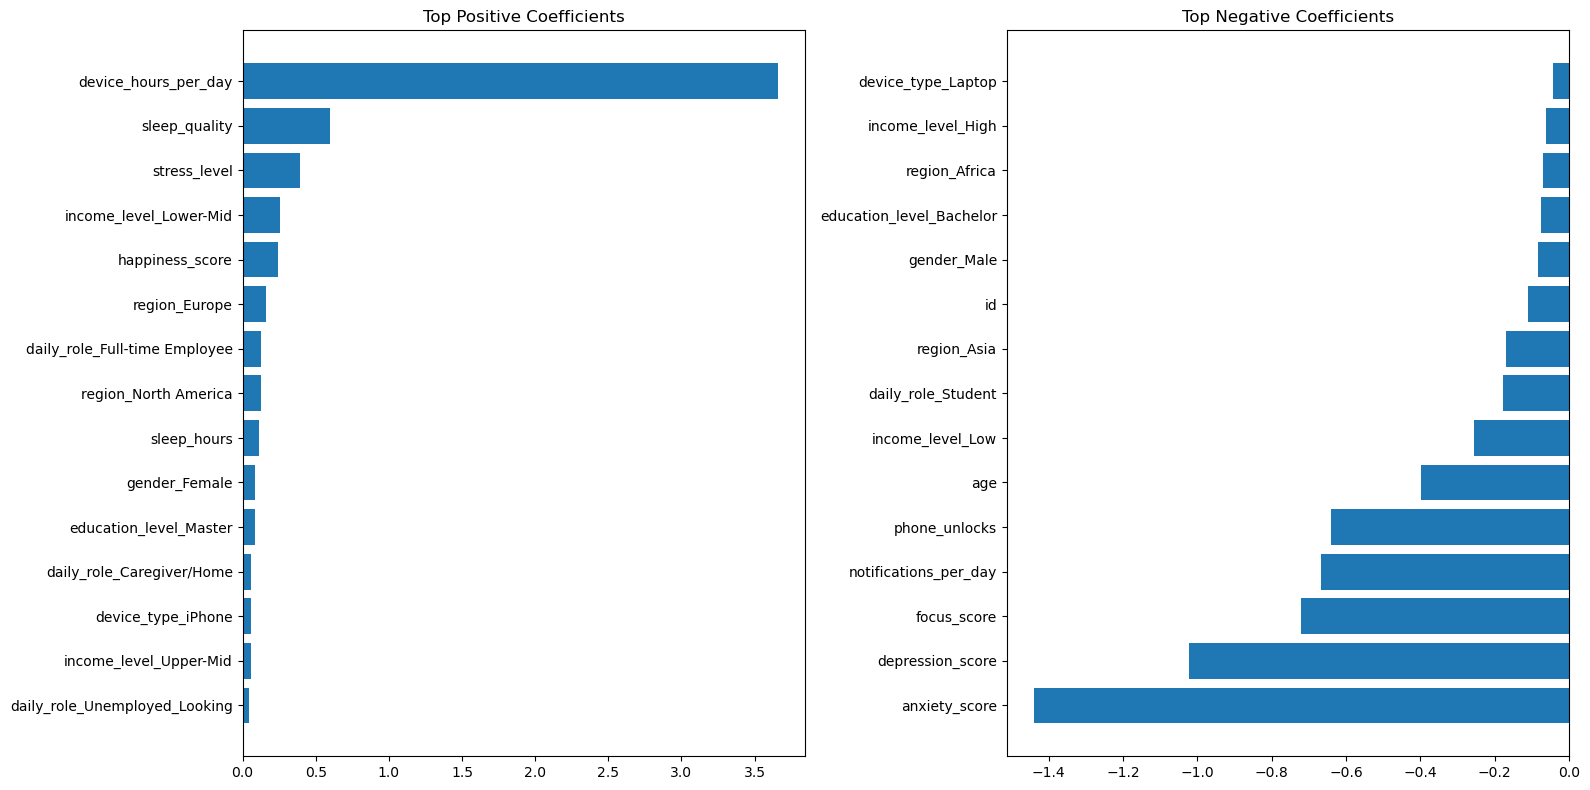

In [54]:
top_positive = coef_df.nlargest(
    15,
    'Coefficient'
).sort_values(
    by='Coefficient',
    ascending=True
)

top_negative = coef_df.nsmallest(
    15,
    'Coefficient'
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16,8)
)

axes[0].barh(top_positive['Feature'], top_positive['Coefficient'])
axes[0].set_title("Top Positive Coefficients")
axes[1].barh(top_negative['Feature'], top_negative['Coefficient'])
axes[1].set_title("Top Negative Coefficients")
plt.tight_layout()
plt.show()

## KNN

In [66]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)
print()
print("TRAINING RESULTS")
print()
print(f"MAE : {train_mae:.4f}")
print(f"MSE : {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"R²  : {train_r2:.4f}")

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)
print()
print("TESTING RESULTS")
print()
print(f"MAE : {test_mae:.4f}")
print(f"MSE : {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²  : {test_r2:.4f}")


TRAINING RESULTS

MAE : 6.8938
MSE : 76.2282
RMSE: 8.7309
R²  : 0.2045

TESTING RESULTS

MAE : 7.8873
MSE : 100.2078
RMSE: 10.0104
R²  : -0.2005


In [67]:
train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

train_mse = mean_squared_error(
    y_train,
    y_train_pred
)

train_rmse = np.sqrt(train_mse)

train_r2 = r2_score(
    y_train,
    y_train_pred
)

print()
print("TRAINING RESULTS")
print()

print(f"MAE : {train_mae:.4f}")
print(f"MSE : {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"R²  : {train_r2:.4f}")

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_mse = mean_squared_error(
    y_test,
    y_test_pred
)

test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(
    y_test,
    y_test_pred
)

print("\n" + "="*50)
print("TESTING RESULTS")
print("="*50)

print(f"MAE : {test_mae:.4f}")
print(f"MSE : {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²  : {test_r2:.4f}")


TRAINING RESULTS

MAE : 6.8938
MSE : 76.2282
RMSE: 8.7309
R²  : 0.2045

TESTING RESULTS
MAE : 7.8873
MSE : 100.2078
RMSE: 10.0104
R²  : -0.2005


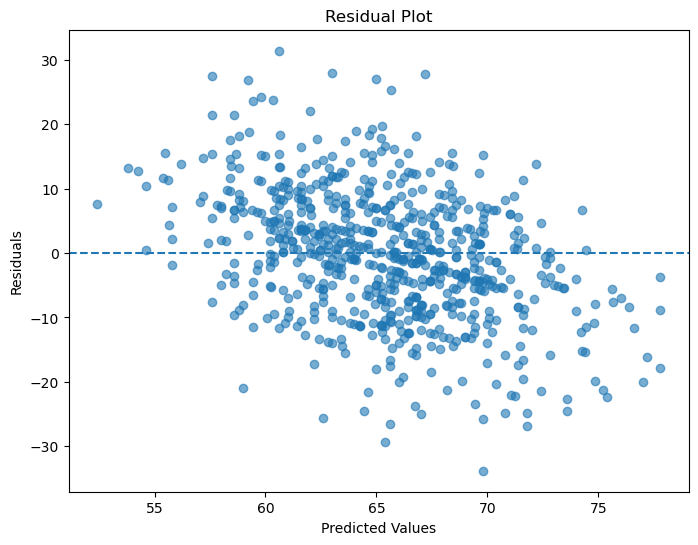

In [68]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# XGBoost

In [69]:
xgb = XGBRegressor(random_state=42)

param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 4, 6],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,          
    cv=5,
    scoring='r2',    
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)
print("Best parameters:", random_search.best_params_)
best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Test MSE:", mse)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
Test MSE: 86.04682987648204


[66.77895  67.830475 67.52951  ... 66.60997  66.41736  64.7896  ]
The MSE of the training set is: 79.82
The Root mean squared error of the training set is: 8.93
The R-squared of the training set is: 0.17
The mean absolute error of the training set is: 6.98
[65.934906 67.30738  63.533016 67.80478  66.36051  69.250305 64.734856
 66.32047  63.259773 66.65251  67.73822  66.44988  66.00115  66.86128
 64.33212  67.37489  63.026886 64.46969  64.55237  64.39867  59.980618
 65.5901   66.97368  65.871925 65.75825  67.61075  65.423836 65.81423
 64.23708  64.9012   65.147354 68.98332  68.43411  65.321754 66.930916
 64.201546 61.83102  65.848145 67.39056  63.88164  66.3632   68.92043
 64.33475  65.461    65.210205 65.18525  64.22618  66.59632  63.867874
 62.775158 63.14419  65.809944 64.96452  64.78176  66.40137  68.72921
 68.667854 66.323006 65.27806  67.680016 61.00343  64.634125 64.41282
 65.94294  66.67033  65.63954  65.23781  67.71105  64.183334 66.42019
 64.97572  64.27304  61.958305 67.95190

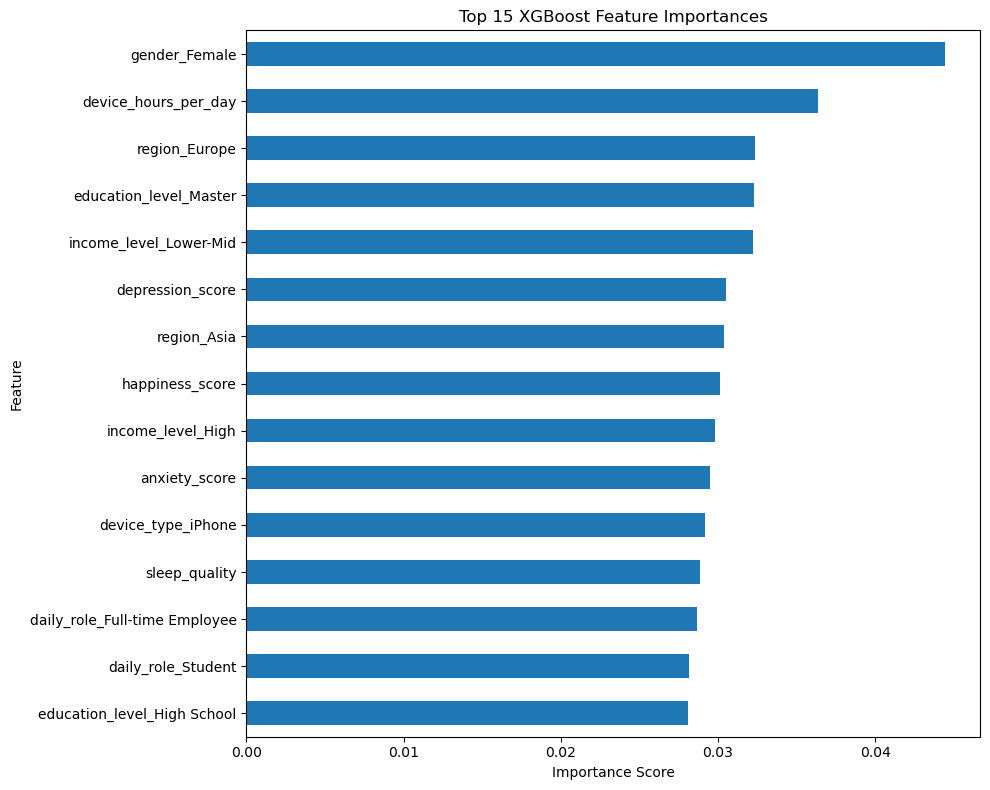

In [71]:
xgb_model = XGBRegressor(
    random_state = 42,
    n_estimators = 200,
    learning_rate = 0.03,
    max_depth = 3,
    subsample = 0.7,
    colsample_bytree = 0.9
)


xgb_model.fit(X_train, y_train)

# Training
y_train_pred = xgb_model.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)


print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = xgb_model.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)


print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

importance_xgb = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
plt.figure(figsize=(10,8))
importance_xgb.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# AdaBoost

In [76]:
base_tree = DecisionTreeRegressor()

ada = AdaBoostRegressor(
    estimator=base_tree,
    random_state=42
)

# Parameter distribution
param_dist_ada = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.5],
    "estimator__max_depth": [2, 3, 4, 6],
    "estimator__min_samples_split": [2, 5, 10]
}

random_search_ada = RandomizedSearchCV(
    estimator=ada,
    param_distributions=param_dist_ada,
    n_iter=40,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    random_state=42
)


random_search_ada.fit(X_train, y_train)
print("Best AdaBoost params:", random_search_ada.best_params_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best AdaBoost params: {'n_estimators': 200, 'learning_rate': 0.01, 'estimator__min_samples_split': 10, 'estimator__max_depth': 6}


[65.68709142 65.56359401 66.22198382 ... 66.19574896 66.19574896
 64.55084399]
The MSE of the training set is: 84.48
The Root mean squared error of the training set is: 9.19
The R-squared of the training set is: 0.12
The mean absolute error of the training set is: 7.19
[64.99298164 66.69563529 63.94191031 66.78046868 65.96644754 66.99271945
 63.46844541 65.80164429 63.78762336 66.70236379 67.0783427  65.83387239
 66.56907692 66.32322602 63.25904616 66.77091941 63.24283218 65.09183609
 65.69600424 64.47163774 60.33333333 65.72516656 66.63644438 66.41547631
 64.47362162 66.56296559 66.19574896 65.88548302 65.01500297 65.73409795
 65.65085474 67.20916333 65.88930362 66.03449847 65.80164429 65.04706305
 63.29693056 65.39887261 66.70529493 64.60813712 66.16530331 67.21928137
 64.3327469  65.74449262 65.67455635 65.05772362 64.45896264 66.21892244
 65.83632733 64.26048484 63.22783448 66.42415118 65.5035318  65.8313854
 66.39370632 66.64262939 66.98405418 66.42415118 65.5440965  66.61711559
 

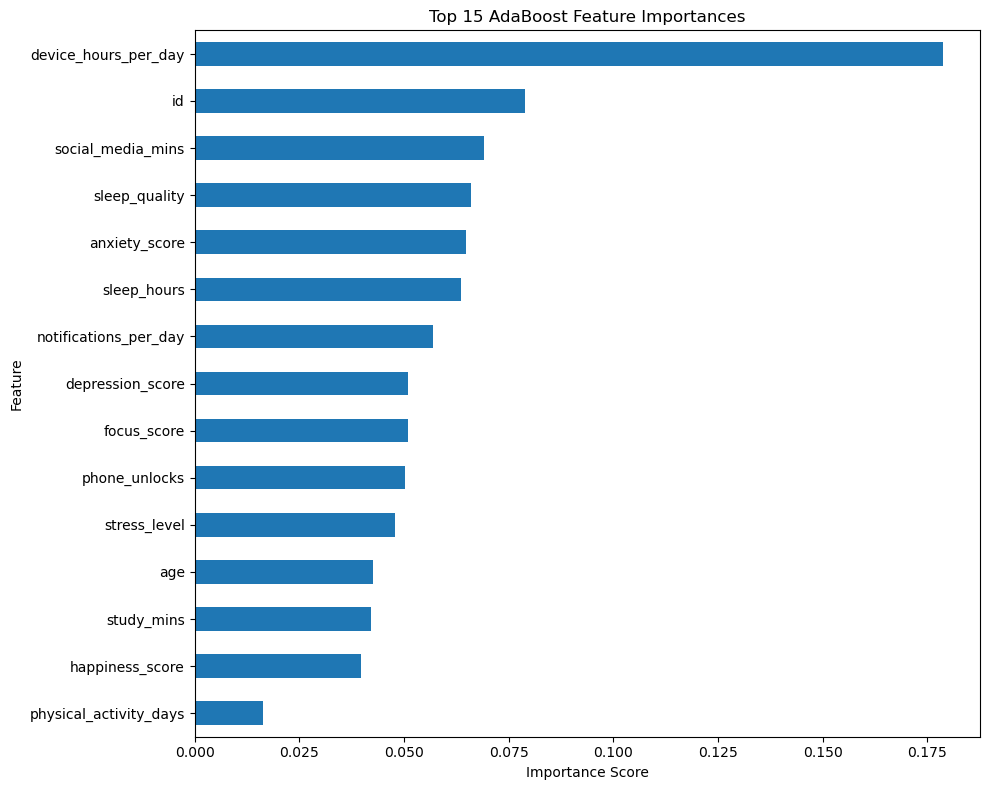

In [77]:
base_tree = DecisionTreeRegressor(
    max_depth=6,
    min_samples_split=10,
    random_state=42
)

abc = AdaBoostRegressor(
    estimator=base_tree,
    n_estimators=200,
    learning_rate=0.01,
    random_state=42
)


abc_model = abc.fit(X_train, y_train)

# Training 

y_train_pred = abc_model.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)
print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = abc_model.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)
print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

importance_abc = pd.Series(
    abc_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
plt.figure(figsize=(10,8))
importance_abc.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 AdaBoost Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# GradientBoosting

In [79]:
gbr = GradientBoostingRegressor(random_state=42)

param_dist = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.05, 0.1],
    "max_depth": [1, 3, 4],   
    "loss": ["squared_error", "huber"],
    "max_features": [None, "sqrt", 5],
    "subsample": [0.7, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

best_gbr = random_search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters:
{'subsample': 1.0, 'n_estimators': 300, 'max_features': None, 'max_depth': 1, 'loss': 'squared_error', 'learning_rate': 0.1}


[61.78435417 65.5179447  66.7494242  ... 65.83853212 66.46657377
 64.59467877]
The MSE of the training set is: 88.74
The Root mean squared error of the training set is: 9.42
The R-squared of the training set is: 0.07
The mean absolute error of the training set is: 7.36
[65.30314902 67.91753975 63.58155698 67.5305947  65.49273885 68.10784817
 63.50682745 65.82794142 63.36563815 66.4475745  67.61685756 66.12770899
 65.94976745 66.10632533 64.26676819 66.90824508 63.54475211 63.19917433
 63.02462161 63.90700073 59.0550248  65.40518529 65.97581161 66.59284592
 65.18510101 66.79019157 65.85020414 65.64777558 65.20071889 65.20175842
 65.17563408 68.2467126  68.78385579 66.22819449 67.07591503 64.33380956
 62.80018542 64.88670775 66.0885619  63.88248703 66.67351838 66.73742209
 63.96810997 65.51124825 64.44673222 63.43444721 63.3698358  66.32245725
 64.04993311 61.59294115 63.8762828  64.92807691 64.50521262 64.33388296
 66.62073395 68.02060776 67.7303266  66.45161534 65.27595455 67.23642756


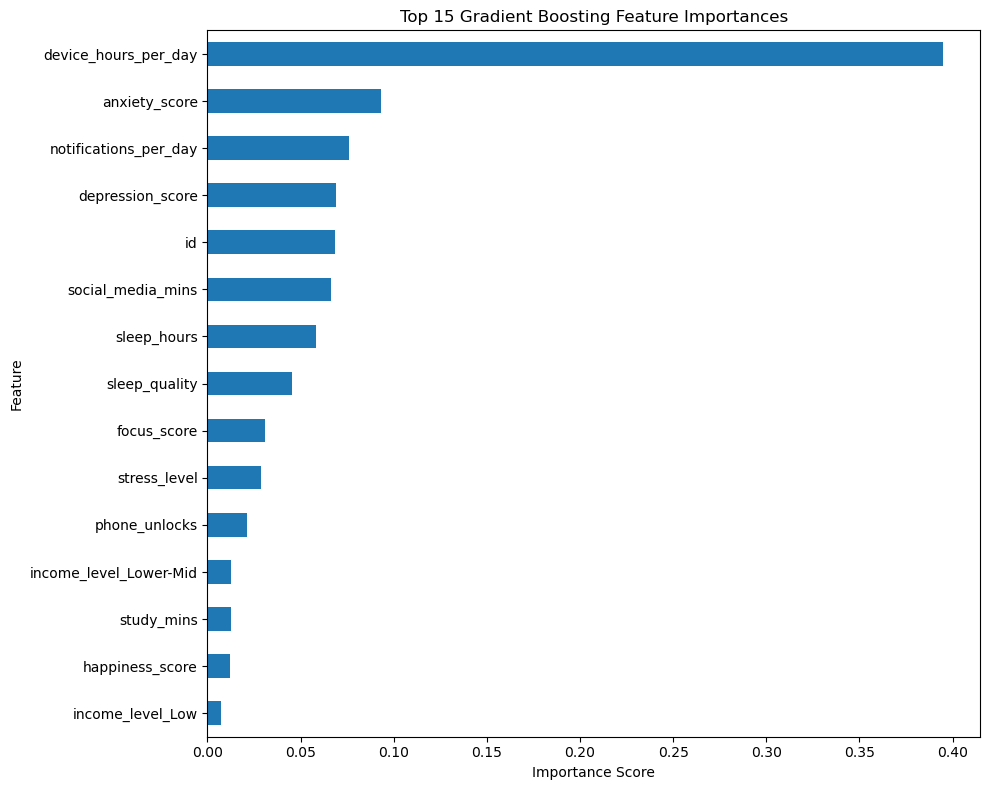

In [81]:
gbr = GradientBoostingRegressor(
    subsample=1.0,
    n_estimators=300,
    max_features=None,
    max_depth=1,
    loss='squared_error',
    learning_rate=0.1,
    random_state=42
)

gbr_model = gbr.fit(X_train, y_train)

# Training 

y_train_pred = gbr.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)

print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = gbr.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)
print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

importance_gbr = pd.Series(
    gbr_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
plt.figure(figsize=(10,8))
importance_gbr.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 Gradient Boosting Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Random forest

In [72]:
rf = RandomForestRegressor(random_state=42)
param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=15,
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search_rf.fit(X_train, y_train)

print("Best Parameters:")
print(random_search_rf.best_params_)

Fitting 15 folds for each of 20 candidates, totalling 300 fits
Best Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 5}


TRAINING RESULTS

The MSE of the training set is: 83.26
The Root mean squared error of the training set is: 9.12
The R-squared of the training set is: 0.13
The mean absolute error of the training set is: 7.13

TESTING RESULTS

The MSE of the testing set is: 84.82
The Root mean squared error of the testing set is: 9.21
The R-squared of the testing set is: -0.02
The mean absolute error of the testing set is: 7.14


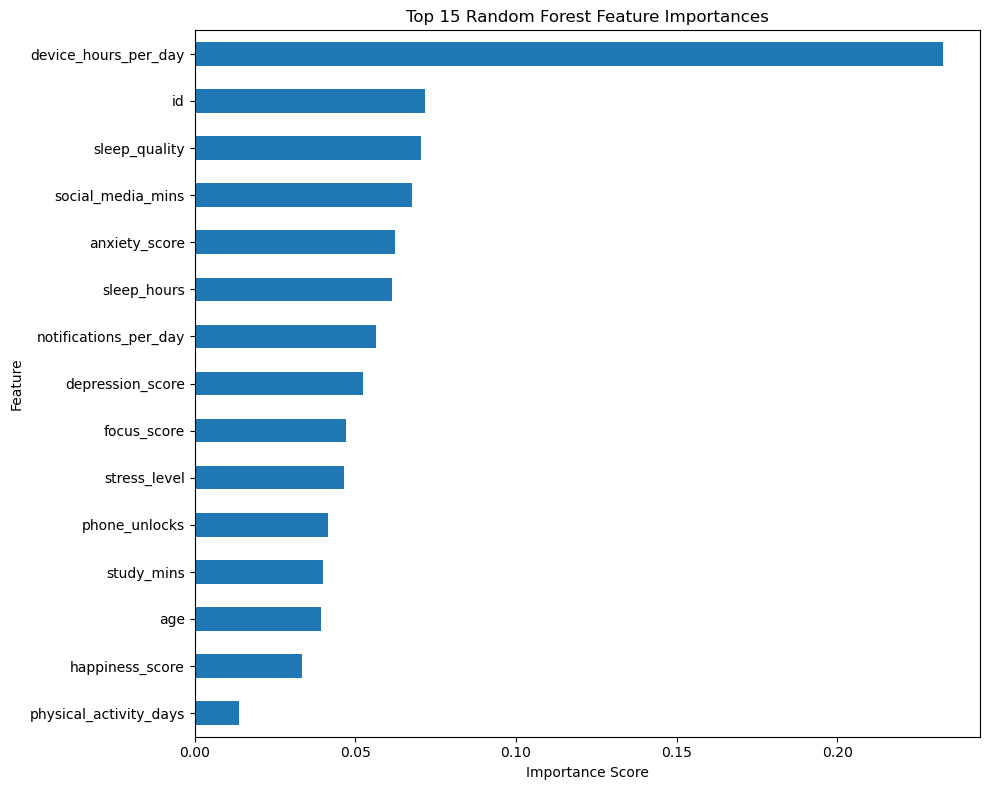

In [73]:
rf_model = RandomForestRegressor(
    random_state=42,
    n_estimators=500,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=None
)

rf_model.fit(X_train, y_train)
y_train_pred = rf_model.predict(X_train)

MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)
print("TRAINING RESULTS")
print()
print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")


y_test_pred = rf_model.predict(X_test)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)
print()
print("TESTING RESULTS")
print()
print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")


importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
plt.figure(figsize=(10,8))
importance_rf.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 3. target: digital_dependence_score
* Regression

In [82]:
cols_drop_3 = ['high_risk_flag', 'productivity_score', 'digital_dependence_score']
X = df.drop(columns = cols_drop_3)
y = df['digital_dependence_score']

In [83]:
X = pd.get_dummies(X, drop_first=False)
print(X.dtypes)

id                                 int64
age                                int64
device_hours_per_day             float64
phone_unlocks                      int64
notifications_per_day              int64
social_media_mins                  int64
study_mins                         int64
physical_activity_days           float64
sleep_hours                      float64
sleep_quality                    float64
anxiety_score                    float64
depression_score                 float64
stress_level                     float64
happiness_score                  float64
focus_score                      float64
gender_Female                       bool
gender_Male                         bool
region_Africa                       bool
region_Asia                         bool
region_Europe                       bool
region_Middle East                  bool
region_North America                bool
region_South America                bool
income_level_High                   bool
income_level_Low

In [84]:
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)
print(X.dtypes)

id                                 int64
age                                int64
device_hours_per_day             float64
phone_unlocks                      int64
notifications_per_day              int64
social_media_mins                  int64
study_mins                         int64
physical_activity_days           float64
sleep_hours                      float64
sleep_quality                    float64
anxiety_score                    float64
depression_score                 float64
stress_level                     float64
happiness_score                  float64
focus_score                      float64
gender_Female                      int64
gender_Male                        int64
region_Africa                      int64
region_Asia                        int64
region_Europe                      int64
region_Middle East                 int64
region_North America               int64
region_South America               int64
income_level_High                  int64
income_level_Low

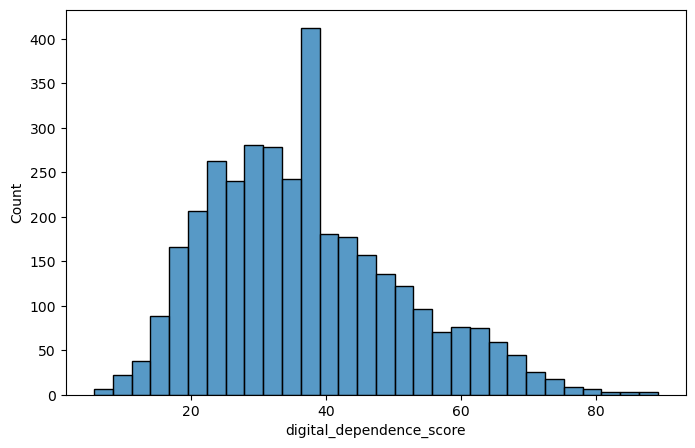

digital_dependence_score    1.000000
device_hours_per_day        0.870963
phone_unlocks               0.837802
depression_score            0.718791
anxiety_score               0.575119
notifications_per_day       0.423947
stress_level                0.346549
high_risk_flag              0.305313
productivity_score          0.039561
age                         0.024508
social_media_mins           0.008808
study_mins                  0.005434
id                          0.001404
physical_activity_days     -0.017302
focus_score                -0.346359
happiness_score            -0.371766
sleep_hours                -0.527715
sleep_quality              -0.593271
Name: digital_dependence_score, dtype: float64


In [86]:
df['digital_dependence_score'].describe()
plt.figure(figsize=(8,5))
sns.histplot(df['digital_dependence_score'], bins=30)
plt.show()


corr_prod_2 = (
    df.corr(numeric_only=True)['digital_dependence_score']
    .sort_values(ascending=False)
)

print(corr_prod_2)

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [88]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [89]:
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

y_train_pred = linreg.predict(X_train_scaled)
y_test_pred = linreg.predict(X_test_scaled)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print()
print("TRAINING RESULTS")
print()
print(f"MAE : {train_mae:.4f}")
print(f"MSE : {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"R²  : {train_r2:.4f}")

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print()
print("TESTING RESULTS")
print()
print(f"MAE : {test_mae:.4f}")
print(f"MSE : {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²  : {test_r2:.4f}")


TRAINING RESULTS

MAE : 0.8563
MSE : 5.8701
RMSE: 2.4228
R²  : 0.9705

TESTING RESULTS

MAE : 0.7096
MSE : 2.8908
RMSE: 1.7002
R²  : 0.9856


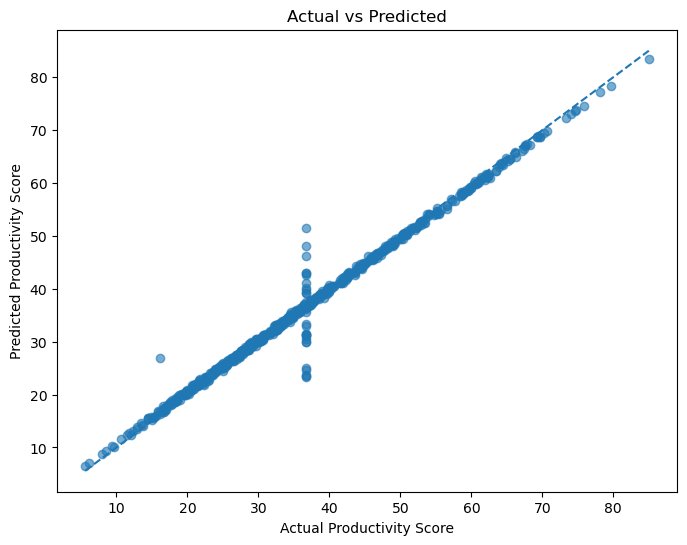

In [90]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_test_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    '--'
)

plt.xlabel("Actual Productivity Score")
plt.ylabel("Predicted Productivity Score")
plt.title("Actual vs Predicted")
plt.show()


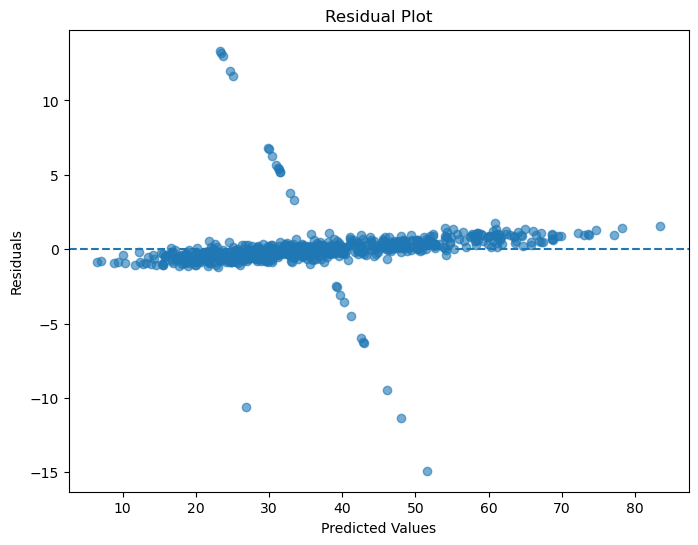

In [91]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8,6))
plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [92]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': linreg.coef_
})

coef_df = coef_df.sort_values(
    by='Coefficient'
)

print(coef_df)

                          Feature  Coefficient
11               depression_score    -0.106568
12                   stress_level    -0.062118
29         education_level_Master    -0.049542
39             device_type_iPhone    -0.042141
22           region_South America    -0.039127
25         income_level_Lower-Mid    -0.037356
19                  region_Europe    -0.032962
13                happiness_score    -0.030284
35  daily_role_Unemployed_Looking    -0.022585
16                    gender_Male    -0.012349
10                  anxiety_score    -0.011557
14                    focus_score    -0.011427
32  daily_role_Full-time Employee    -0.011005
27       education_level_Bachelor    -0.008869
31      daily_role_Caregiver/Home    -0.008587
0                              id    -0.005327
7          physical_activity_days    -0.004244
26         income_level_Upper-Mid    -0.002638
9                   sleep_quality    -0.001024
8                     sleep_hours    -0.000787
38           

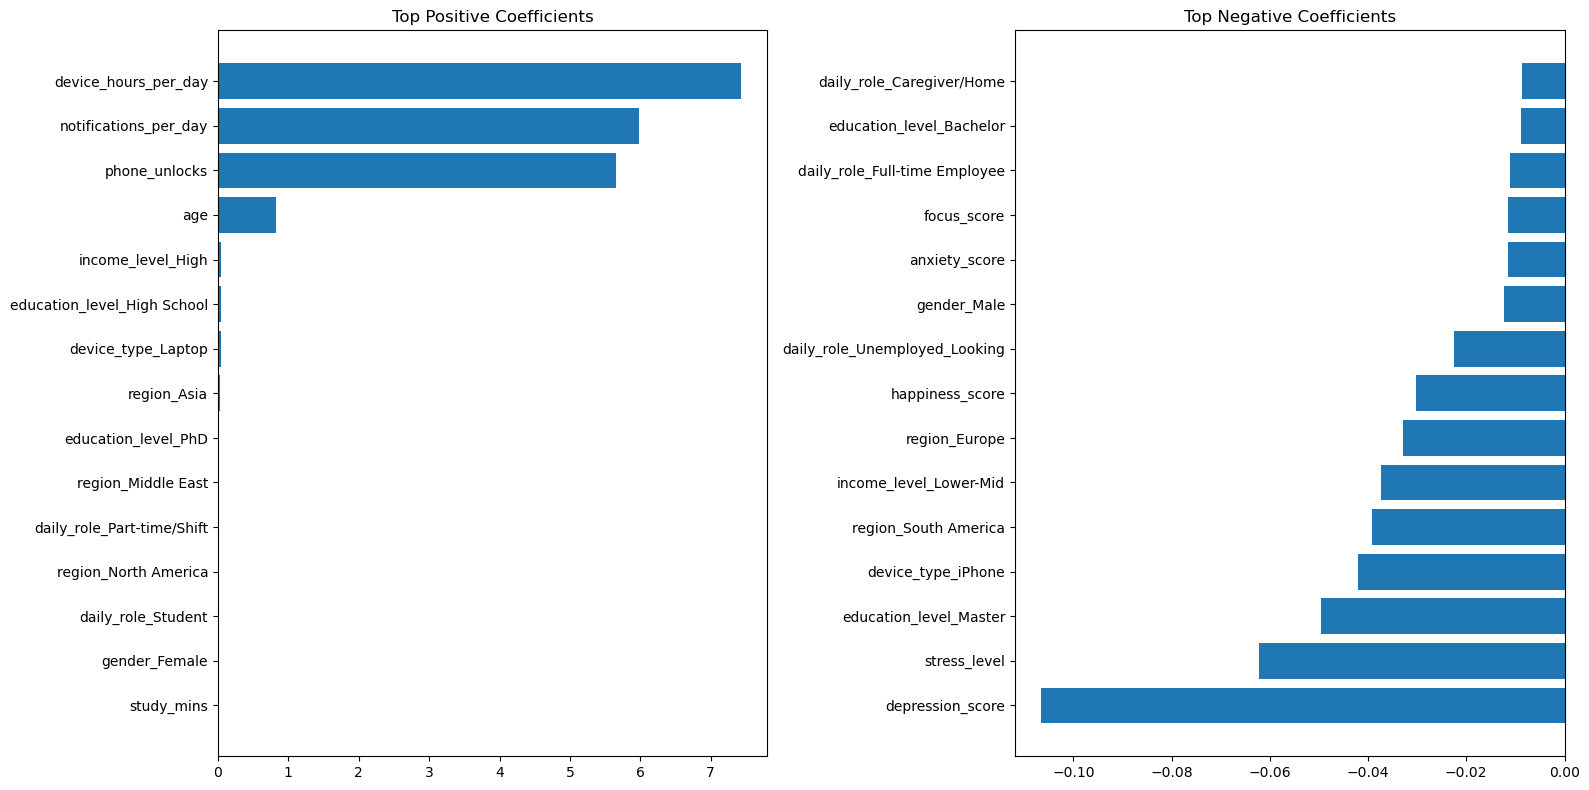

In [93]:
top_positive = coef_df.nlargest(
    15,
    'Coefficient'
).sort_values(
    by='Coefficient',
    ascending=True
)

top_negative = coef_df.nsmallest(
    15,
    'Coefficient'
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16,8)
)

axes[0].barh(top_positive['Feature'], top_positive['Coefficient'])
axes[0].set_title("Top Positive Coefficients")
axes[1].barh(top_negative['Feature'], top_negative['Coefficient'])
axes[1].set_title("Top Negative Coefficients")
plt.tight_layout()
plt.show()

## KNN

In [94]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)
print()
print("TRAINING RESULTS")
print()
print(f"MAE : {train_mae:.4f}")
print(f"MSE : {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"R²  : {train_r2:.4f}")

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)
print()
print("TESTING RESULTS")
print()
print(f"MAE : {test_mae:.4f}")
print(f"MSE : {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²  : {test_r2:.4f}")


TRAINING RESULTS

MAE : 4.9381
MSE : 38.5181
RMSE: 6.2063
R²  : 0.8063

TESTING RESULTS

MAE : 6.1311
MSE : 57.1540
RMSE: 7.5600
R²  : 0.7147


In [95]:
train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

train_mse = mean_squared_error(
    y_train,
    y_train_pred
)

train_rmse = np.sqrt(train_mse)

train_r2 = r2_score(
    y_train,
    y_train_pred
)

print()
print("TRAINING RESULTS")
print()

print(f"MAE : {train_mae:.4f}")
print(f"MSE : {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"R²  : {train_r2:.4f}")

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_mse = mean_squared_error(
    y_test,
    y_test_pred
)

test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(
    y_test,
    y_test_pred
)

print("\n" + "="*50)
print("TESTING RESULTS")
print("="*50)

print(f"MAE : {test_mae:.4f}")
print(f"MSE : {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²  : {test_r2:.4f}")


TRAINING RESULTS

MAE : 4.9381
MSE : 38.5181
RMSE: 6.2063
R²  : 0.8063

TESTING RESULTS
MAE : 6.1311
MSE : 57.1540
RMSE: 7.5600
R²  : 0.7147


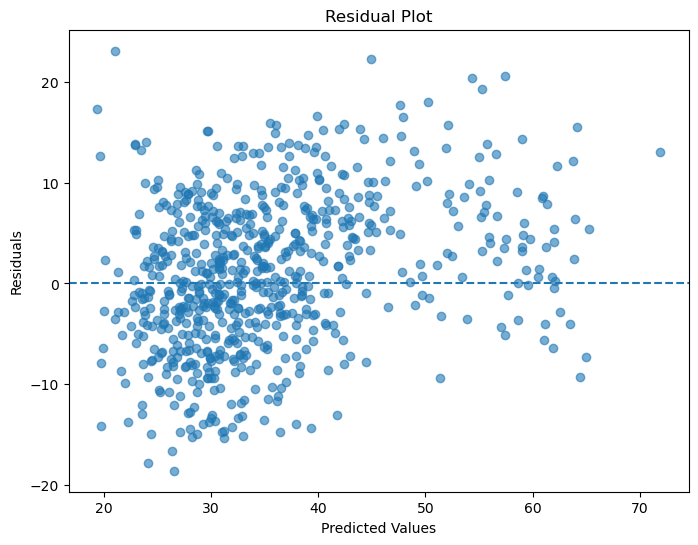

In [96]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

## XGBoost

In [97]:
xgb = XGBRegressor(random_state=42)

param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 4, 6],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,          
    cv=5,
    scoring='r2',    
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)
print("Best parameters:", random_search.best_params_)
best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Test MSE:", mse)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Test MSE: 3.128153008971767


[30.866228 20.584753 36.033463 ... 32.419697 42.378864 23.73601 ]
The MSE of the training set is: 0.69
The Root mean squared error of the training set is: 0.83
The R-squared of the training set is: 1.00
The mean absolute error of the training set is: 0.54
[31.914915  44.30628   16.056437  37.885864  31.548674  39.371185
 26.551437  23.601255  11.9338455 30.55435   33.61344   43.58873
 45.400818  50.49367   21.742783  33.27351   15.874373  23.311525
 65.61654   21.182306  13.506509  24.03876   29.449516  49.996716
 22.107786  40.751534  60.03048   27.956339  34.388256  60.549618
 29.379187  42.011517  69.483376  50.577583  46.45583   36.436573
 41.198265  37.1981    33.888985  19.870066  36.673466  32.672585
 37.875195  33.60571   29.46651   42.098404  13.206692  27.303051
 65.61061   20.688896  29.506273  57.39645   34.275196  60.76841
 35.27941   53.40458   35.805225  62.407406  45.88874   29.025099
 14.403438  19.69543   22.34792   44.264496  26.84499   38.704227
 28.096804  35.88746

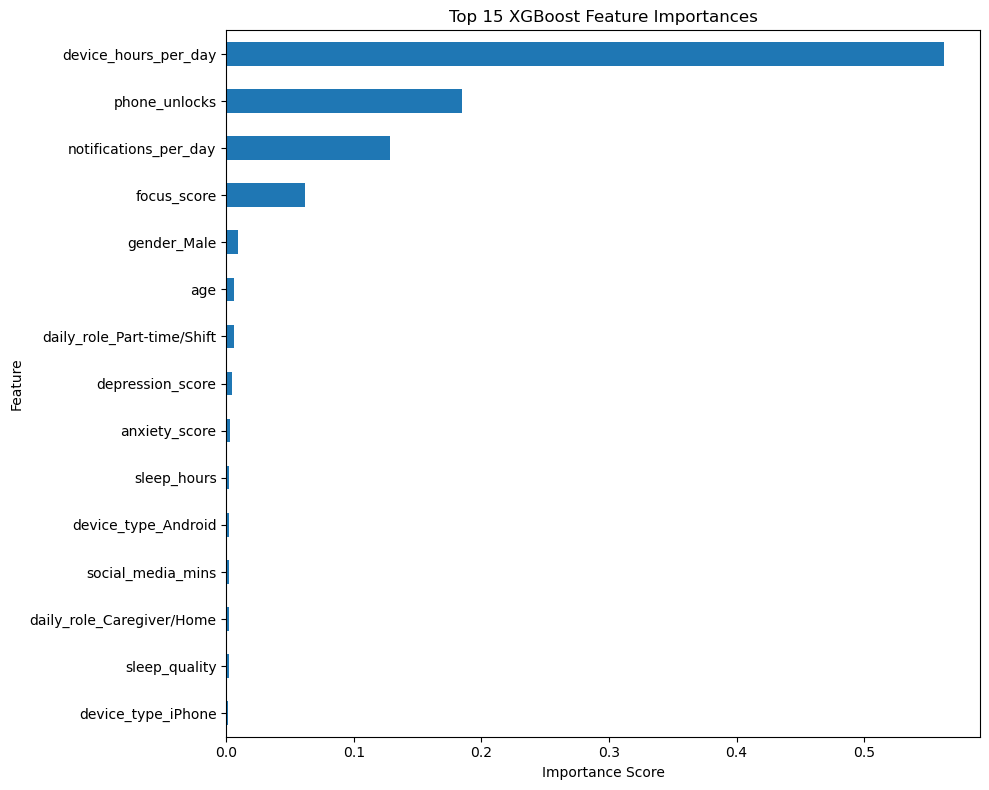

In [98]:
xgb_model = XGBRegressor(
    random_state = 42,
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 4,
    subsample = 1.0,
    colsample_bytree = 0.9
)


xgb_model.fit(X_train, y_train)

# Training
y_train_pred = xgb_model.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)


print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = xgb_model.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)


print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

importance_xgb = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
plt.figure(figsize=(10,8))
importance_xgb.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## AdaBoost

In [99]:
base_tree = DecisionTreeRegressor()

ada = AdaBoostRegressor(
    estimator=base_tree,
    random_state=42
)

# Parameter distribution
param_dist_ada = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.5],
    "estimator__max_depth": [2, 3, 4, 6],
    "estimator__min_samples_split": [2, 5, 10]
}

random_search_ada = RandomizedSearchCV(
    estimator=ada,
    param_distributions=param_dist_ada,
    n_iter=40,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    random_state=42
)


random_search_ada.fit(X_train, y_train)
print("Best AdaBoost params:", random_search_ada.best_params_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best AdaBoost params: {'n_estimators': 300, 'learning_rate': 0.5, 'estimator__min_samples_split': 2, 'estimator__max_depth': 6}


[33.48719535 21.92349341 34.75529281 ... 34.30817104 44.0375
 25.61420305]
The MSE of the training set is: 3.52
The Root mean squared error of the training set is: 1.88
The R-squared of the training set is: 0.98
The mean absolute error of the training set is: 1.57
[32.95525949 42.21697069 18.34914286 38.86237249 33.25183754 40.23747213
 26.081006   23.87679399 13.99622642 33.04492145 34.40068493 45.37760552
 46.38986237 51.5037582  21.82882468 35.38759924 16.51129032 23.26944459
 64.27       22.0339081  16.3527027  27.63417193 31.92907197 48.2304878
 23.28045893 41.38033455 58.43297872 29.96006327 33.58363565 60.175
 31.07177894 43.54       67.40740741 49.78181818 45.19082706 37.82539216
 38.44545455 38.65894017 33.5931854  20.43409091 37.40141107 33.48268004
 37.8128707  34.24123566 27.73731864 39.49167388 15.06818182 29.90087673
 65.55208333 22.40512821 27.54463955 57.159375   37.43341242 59.03333333
 35.8804878  54.58915663 34.53869618 60.26029412 45.93636364 29.34210526
 18.0852216

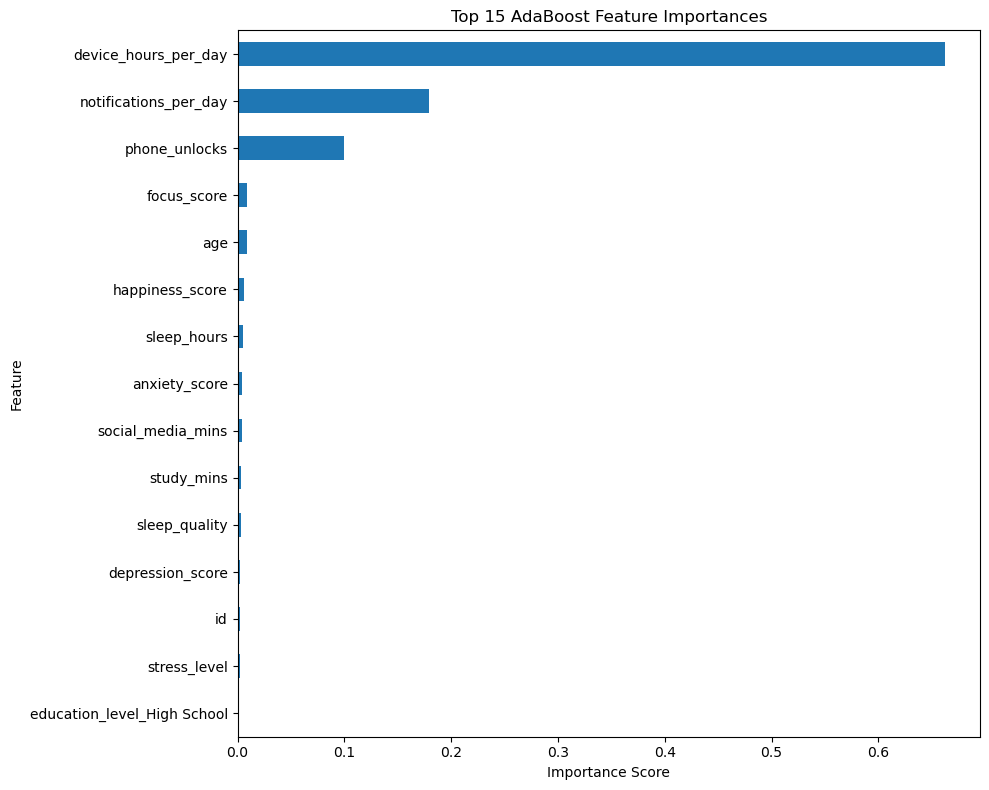

In [100]:
base_tree = DecisionTreeRegressor(
    max_depth=6,
    min_samples_split=2,
    random_state=42
)

abc = AdaBoostRegressor(
    estimator=base_tree,
    n_estimators=300,
    learning_rate=0.5,
    random_state=42
)


abc_model = abc.fit(X_train, y_train)

# Training 

y_train_pred = abc_model.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)
print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = abc_model.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)
print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

importance_abc = pd.Series(
    abc_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
plt.figure(figsize=(10,8))
importance_abc.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 AdaBoost Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Gradient Boosting

In [101]:
gbr = GradientBoostingRegressor(random_state=42)

param_dist = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.05, 0.1],
    "max_depth": [1, 3, 4],   
    "loss": ["squared_error", "huber"],
    "max_features": [None, "sqrt", 5],
    "subsample": [0.7, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

best_gbr = random_search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters:
{'subsample': 0.7, 'n_estimators': 300, 'max_features': None, 'max_depth': 4, 'loss': 'squared_error', 'learning_rate': 0.1}


[30.4718564  20.51932701 35.69563125 ... 32.31508678 42.40538017
 23.60301628]
The MSE of the training set is: 0.48
The Root mean squared error of the training set is: 0.69
The R-squared of the training set is: 1.00
The mean absolute error of the training set is: 0.50
[31.80505824 43.78474864 15.73196395 37.9794455  31.62644866 38.68497893
 26.25845269 23.82102117 12.86509415 31.78780137 33.50106663 44.34230304
 46.36829113 51.43736523 20.90546361 33.81019661 18.86123195 23.72272954
 66.99928283 20.62029149 15.2330507  23.03273199 30.4051234  50.35310602
 22.05252209 41.50358294 60.51542414 27.49043349 33.41472416 62.2557405
 30.26119986 42.92019426 69.00652881 51.72320134 45.58659235 37.67555332
 37.79595809 37.41163248 33.70020876 19.92650312 36.67982382 33.67361504
 37.7327431  33.45879309 27.99417525 42.04252843 13.00239178 27.76856902
 67.10297154 21.16529827 28.81116473 55.12586766 34.1522028  60.32520856
 35.03070244 52.90684375 34.79472006 60.69011798 44.68896718 29.92848282
 1

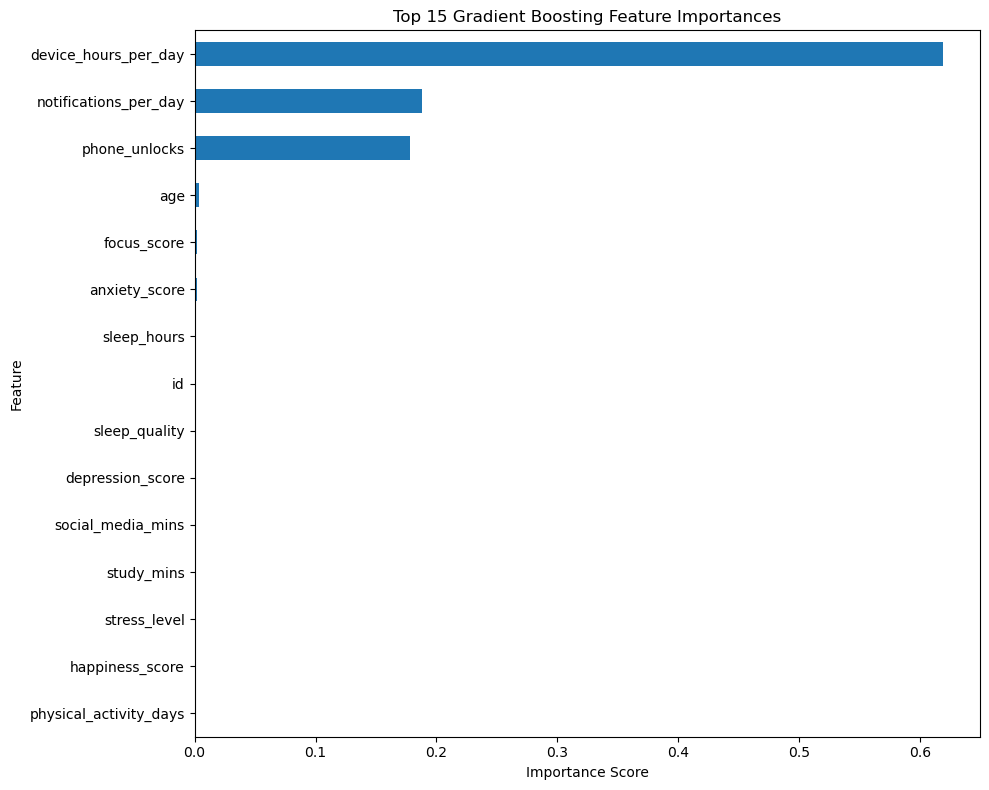

In [102]:
gbr = GradientBoostingRegressor(
    subsample=0.7,
    n_estimators=300,
    max_features=None,
    max_depth=4,
    loss='squared_error',
    learning_rate=0.1,
    random_state=42
)

gbr_model = gbr.fit(X_train, y_train)

# Training 

y_train_pred = gbr.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)

print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = gbr.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)
print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

importance_gbr = pd.Series(
    gbr_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
plt.figure(figsize=(10,8))
importance_gbr.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 Gradient Boosting Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Random forest

In [103]:
rf = RandomForestRegressor(random_state=42)
param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=15,
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search_rf.fit(X_train, y_train)

print("Best Parameters:")
print(random_search_rf.best_params_)

Fitting 15 folds for each of 20 candidates, totalling 300 fits
Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None}


TRAINING RESULTS

The MSE of the training set is: 1.21
The Root mean squared error of the training set is: 1.10
The R-squared of the training set is: 0.99
The mean absolute error of the training set is: 0.59

TESTING RESULTS

The MSE of the testing set is: 4.00
The Root mean squared error of the testing set is: 2.00
The R-squared of the testing set is: 0.98
The mean absolute error of the testing set is: 1.28


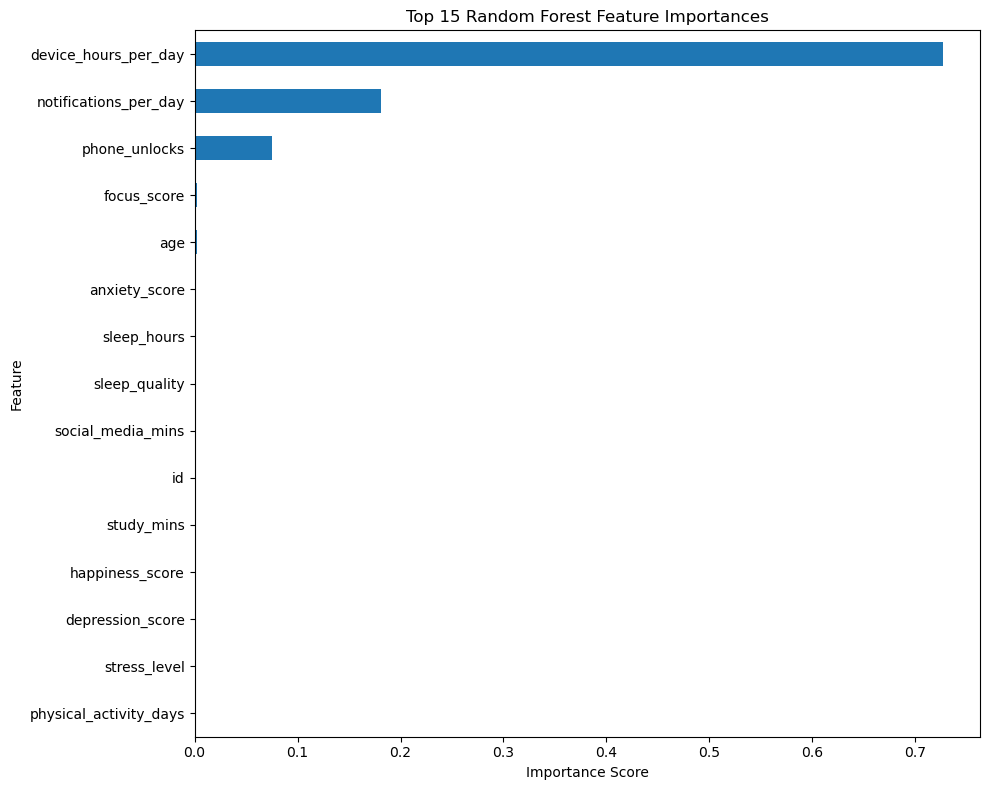

In [104]:
rf_model = RandomForestRegressor(
    random_state=42,
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=None
)

rf_model.fit(X_train, y_train)
y_train_pred = rf_model.predict(X_train)

MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)
print("TRAINING RESULTS")
print()
print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")


y_test_pred = rf_model.predict(X_test)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)
print()
print("TESTING RESULTS")
print()
print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")


importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
plt.figure(figsize=(10,8))
importance_rf.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Feature Engineering